# Sprint: Machine Learning

## Cardiovascular Disease Prediction

### Table of Contents

1. [Introduction](#introduction)
2. [Data Import](#data-import)
3. [Most critical data cleaning](#most-critical-data-cleaning)
4. [Exploratory Data Analysis (EDA)](#exploratory-data-analysis-eda)
5. [Splitting dataset](#splitting-dataset)
6. [Creating pipeline to address data issues](#creating-pipeline-to-address-data-issues)
7. [Variable selection](#variable-selection)
8. [Fitting logistic regression](#fitting-logistic-regression)
9. [Results](#results)
10. [Recommendations](#recommendations)
11. [Possible analysis improvements](#possible-analysis-improvements)

*P.S. Clickable ToC function works in Jupiter notebook environment.*


### Introduction

#### Dataset
This project uses [Cardiovascular Study Dataset](https://www.kaggle.com/datasets/christofel04/cardiovascular-study-dataset-predict-heart-disea/data) from Kaggle. It's sourced from from an ongoing cardiovascular study on residents of the town of Framingham, Massachusetts, also known as Framingham Heart Study. 

#### Goal of the analysis

Perform an analysis and fit a logistic regression model for predicting 10-year risk of coronary heart disease (CHD). Then, choose the most appropriate classification metric for this problem and calculate the optimal threshold.

### Data Import

Below are imported all needed libraries for analysis and visualization. 

For context, this notebook was created in VS Code environment. 

In [96]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.collections 
from matplotlib.colors import LinearSegmentedColormap 
import seaborn as sns

%matplotlib inline

from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, 
    confusion_matrix,
    fbeta_score, 
    log_loss, 
    make_scorer, 
    precision_score,
    recall_score
)
from sklearn.model_selection import (
    GridSearchCV, 
    StratifiedKFold, 
    cross_validate,
    train_test_split,
    TunedThresholdClassifierCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer, 
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)

from statsmodels.stats.outliers_influence import variance_inflation_factor

Next, imported data and visualized 1st 5 rows. Also, checked it's shape (how many rows and columns it has).

In [3]:
df = pd.read_csv(
    "train.csv",
    index_col=0
)

df.head()

,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
id,,,,,,,,,,,,,,,,
0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


In [4]:
df.shape

(3390, 16)

### Most critical data cleaning

#### Data validity 

First, brief overview of data and initial distributions.

In [5]:
df.describe(include="all")

,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,3390.000000,3303.000000,3390,3390,3368.000000,3346.000000,3390.000000,3390.000000,3390.000000,3352.000000,3390.00000,3390.000000,3376.000000,3389.000000,3086.000000,3390.000000
unique,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,F,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1923,1703,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,49.542183,1.970936,NaN,NaN,9.069477,0.029886,0.006490,0.315339,0.025664,237.074284,132.60118,82.883038,25.794964,75.977279,82.086520,0.150737
std,8.592878,1.019081,NaN,NaN,11.879078,0.170299,0.080309,0.464719,0.158153,45.247430,22.29203,12.023581,4.115449,11.971868,24.244753,0.357846
min,32.000000,1.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.50000,48.000000,15.960000,45.000000,40.000000,0.000000
25%,42.000000,1.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.00000,74.500000,23.020000,68.000000,71.000000,0.000000
50%,49.000000,2.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.50000,82.000000,25.380000,75.000000,78.000000,0.000000
75%,56.000000,3.000000,NaN,NaN,20.000000,0.000000,0.000000,1.000000,0.000000,264.000000,144.00000,90.000000,28.040000,83.000000,87.000000,0.000000


Age range seems reasonable, does not have clearly incorrect values. 
Not all variables are explained, like education, on Kaggle. However, in other sources about this study, like [here](https://biolincc.nhlbi.nih.gov/media/teachingstudies/FHS_Teaching_Longitudinal_Data_Documentation_2021a.pdf?link_time=2024-05-26_10:36:20.705109), it seems to refer to attained education. Values from 1-4 are just encodings for:
- 1 = 0-11 years.
- 2 = High School Diploma, GED.
- 3 = Some College, Vocational School.
- 4 = College (BS, BA) degree or more.

In dataset it does fall within this range, thus also does not seem to have clearly incorrect data. 

Sex has to 2 unique categories in this dataset, male and female. There seems to be no other values in this column. 

is_smoking feature refers to boolean values of yes and no. Column has correct number of unique values here as well. 

cigsPerDay is continuous variable with highest value of 70. In previously referred dataset explanation document, it indicates that it can range up to 90 even. Thus, this maximum value is within reasonable range. Also, 0 means person is a non-smoker. 

BPMeds, prevalentStroke, prevalentHyp and diabetes are all also boolean variables coded as 0 and 1 only, 0 indicating a negative and 1 indicating positive answers. Values here are also within expected range. 

totChol is serum total cholesterol (mg/dL). Dataset explanation indicates expected range to be 107-696. Values here indeed are within this range. 

sysBP is systolic blood pressure and is a mean of last two of three measurements (mmHg). Expected range is 83.5-295 and here it is the same. 

diaBP is diastolic blood pressure. Similar to before, it's also a mean of last two of three measurements (mmHg). Expected range is 30-150 and in our dataset values fall within it as well. 

BMI is body mass index, weight in kilograms/height meters squared. It should be within 14.43-56.8 and indeed it is. 

heartRate is counted as beats/min and should be in 37-220 range. Here it indeed falls within it, not very close to maximum values of full research dataset even.

glucose is casual serum glucose (mg/dL) and should have range of 39-478. Again, dataset is within that range. 

Last variable is TenYearCHD, variable which will have to be predicted - 10-year risk of coronary heart disease. It has 0 and 1 values for 0 meaning no and 1 meaning yes. 

Overall, this dataset looks quite clean and does not seem to have clearly invalid records. 

#### Missing values

Next, needed to check if there are significant numbers of missing values in date and if target variable has any. 

In [6]:
missing_values = pd.DataFrame(
    df
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_values = missing_values.rename(
    columns={0: "count"}
)

missing_values["percentage"] = (
    (df.isnull().sum() / len(df)) 
    * 100
    ).round(2)

missing_values

,count,percentage
glucose,304,8.97
education,87,2.57
BPMeds,44,1.30
totChol,38,1.12
cigsPerDay,22,0.65
BMI,14,0.41
heartRate,1,0.03
age,0,0.00
prevalentHyp,0,0.00
prevalentStroke,0,0.00


Target variable does not have any missing values. Also, highest missing value percentage is around 9%, which imputation at later steps will be able to deal with. For now, no further actions are needed until dataset is not split. 

#### Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

Seems to not have duplicates. Also, id column is unique as it worked to be set as index in data reading stage. 

#### Data types

In [8]:
df.dtypes

age                  int64
education          float64
sex                 object
is_smoking          object
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

Dataset does seem to have inconstant data types:
1. Education should have categorical ordinal data type as higher number refers to higher education level. 
2. Sex should be encoded as categorical nominal variable. 
3. is_smoking, BPMeds, prevalentStroke, prevalentHyp, diabetes and TenYearCHD should all have similar boolean values and be categorical type. 

Later on all categorical variables will be encoded. However, for EDA, alining their visual representation is gonna be important. 

Other data types can stay the same. 

**Changing data types**

In [9]:
categorical_columns = [
    "education",
    "sex",
    "is_smoking",
    "BPMeds",
    "prevalentStroke",
    "prevalentHyp",
    "diabetes",
    "TenYearCHD"
]

for col in categorical_columns:
    df[col] = df[col].astype("category")

df["education"] = pd.Categorical(df["education"], ordered=True)

df.dtypes

age                   int64
education          category
sex                category
is_smoking         category
cigsPerDay          float64
BPMeds             category
prevalentStroke    category
prevalentHyp       category
diabetes           category
totChol             float64
sysBP               float64
diaBP               float64
BMI                 float64
heartRate           float64
glucose             float64
TenYearCHD         category
dtype: object

In [10]:
df["education"].dtype

CategoricalDtype(categories=[1.0, 2.0, 3.0, 4.0], ordered=True, categories_dtype=float64)

**Updating categorical data values**

In [11]:
df["education"] = df["education"].cat.rename_categories({
    1: "0-11 years",
    2: "High School Diploma, GED",
    3: "Some College, Vocational School",
    4: "College (BS, BA) degree or more"
})

df["sex"] = df["sex"].cat.rename_categories({
    "F": "Female",
    "M": "Male"
})

df["is_smoking"] = df["is_smoking"].cat.rename_categories({
    "YES": "Yes",
    "NO": "No"
})

binary_cols = ["BPMeds", "prevalentStroke", "prevalentHyp", "diabetes", "TenYearCHD"]
for col in binary_cols:
    df[col] = df[col].cat.rename_categories({
        1: "Yes",
        0: "No"
    })

In [12]:
df.head()

,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
id,,,,,,,,,,,,,,,,
0,64,"High School Diploma, GED",Female,Yes,3.0,No,No,No,No,221.0,148.0,85.0,NaN,90.0,80.0,Yes
1,36,"College (BS, BA) degree or more",Male,No,0.0,No,No,Yes,No,212.0,168.0,98.0,29.77,72.0,75.0,No
2,46,0-11 years,Female,Yes,10.0,No,No,No,No,250.0,116.0,71.0,20.35,88.0,94.0,No
3,50,0-11 years,Male,Yes,20.0,No,No,Yes,No,233.0,158.0,88.0,28.26,68.0,94.0,Yes
4,64,0-11 years,Female,Yes,30.0,No,No,No,No,241.0,136.5,85.0,26.42,70.0,77.0,No


### Exploratory Data Analysis (EDA)

Below I defined functions which will be used to help visualize categorical and numeric variables with a color split to the target one. 

In [13]:
def countplot_style(data, x_column, hue_column_name, title, legend_title, ax=None):  
    
    if ax is None:
        fig, ax = plt.subplots(
            figsize=(15, 6)
        )

    n_hue_categories = len(data[hue_column_name].unique())
    
    sns.countplot(
        data=data,
        x=x_column,
        hue=hue_column_name,
        palette=sns.color_palette(
            "Set2", 
            n_colors=n_hue_categories
        ),
        ax=ax  
    )

    ax.set_title(title)
    
    total = len(data)

    for container in ax.containers:
        for i, container in enumerate(ax.containers):
            heights = [v.get_height() for v in container]
            percentages = [f"{int(h)} ({(h/total)*100:.1f}%)" for h in heights]
            ax.bar_label(
            container,
            labels=percentages,
            label_type="edge",
            padding=3,
            color=sns.color_palette(
                "Set2", 
                n_colors=n_hue_categories
            )[i],
            fontsize=10,
            fontweight="bold"
            )

    sns.despine(
        left=True,
        bottom=True,
        ax=ax
    )

    ax.set(
        xlabel=None,
        ylabel=None
    )

    ax.tick_params(
        axis="both",
        which="both",
        length=0,
    )

    ax.tick_params(
            axis="y",
            labelcolor="gray"
        )
    
    ax.legend(
        title=legend_title,
        frameon=False,
        ncol=2
    )

    if ax is None:
        plt.show()

In [14]:
def histplot_style(data, x_column, hue_column_name, title, legend_title, bins, ax=None):  
    
    if ax is None:
        fig, ax = plt.subplots(
            figsize=(15, 6)
        )

    n_hue_categories = len(data[hue_column_name].unique())
    
    sns.histplot(
        data=data,
        x=x_column,
        hue=hue_column_name,
        multiple="stack",
        kde=True,
        palette=sns.color_palette(
            "Set2", 
            n_colors=n_hue_categories
        ),
        edgecolor="white",
        bins=bins,
        ax=ax  
    )

    ax.set_title(title)

    sns.despine(
        left=True,
        bottom=True,
        ax=ax
    )

    ax.set(
        xlabel=None,
        ylabel=None
    )

    ax.tick_params(
        axis="both",
        which="both",
        length=0
    )

    ax.tick_params(
        axis="y",
        labelcolor="gray"
    )
    
    legend = ax.get_legend()
    legend.set_title(legend_title)
    legend.set_frame_on(False)
    legend._ncol = 2

    if ax is None:
        plt.show()

#### Categorical features

C:\Users\Agne\AppData\Local\Temp\ipykernel_11708\3991967749.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


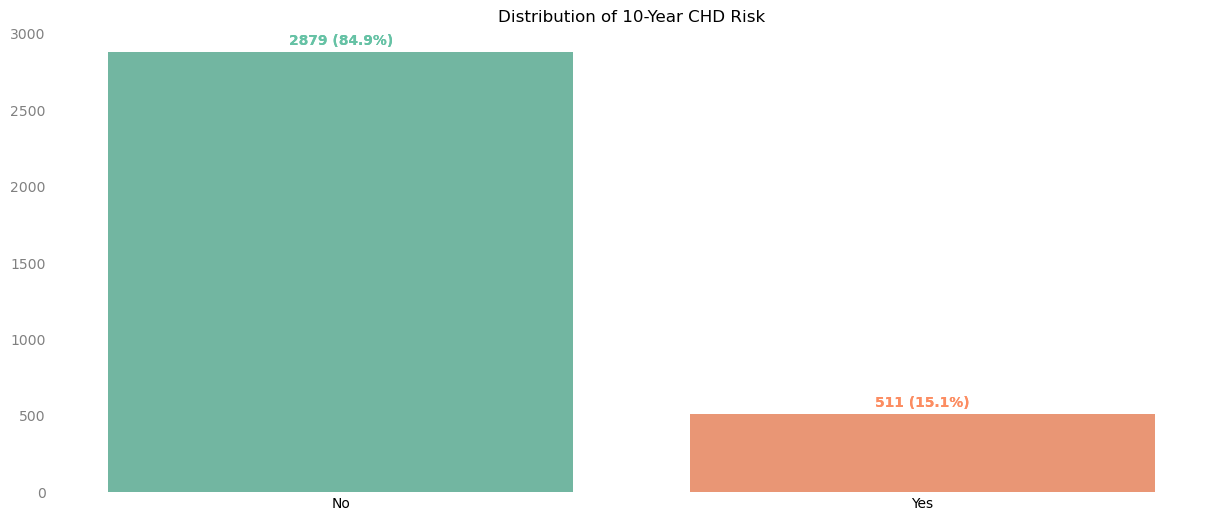

In [15]:
countplot_style(
    data=df,
    x_column=df["TenYearCHD"],
    hue_column_name="TenYearCHD",
    title="Distribution of 10-Year CHD Risk",
    legend_title=""
)

It is visible that data has higher representation of negative than positive CHD risk values. This causes class imbalance problems. This will need to be kept in mind when deciding on data splitting and model training approaches. 

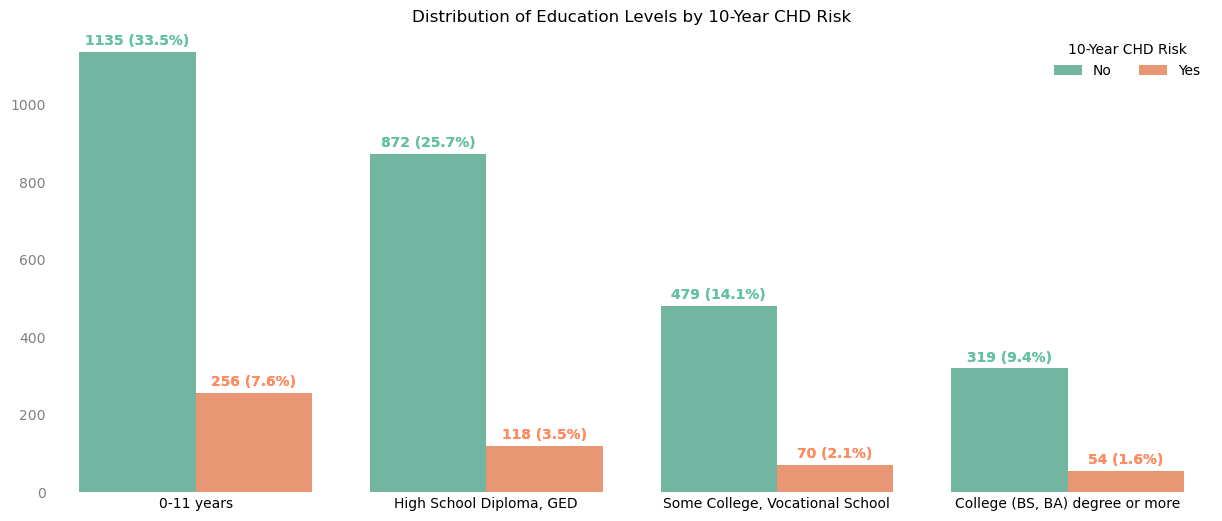

In [16]:
countplot_style(
    data=df,
    x_column=df["education"],
    hue_column_name="TenYearCHD",
    title="Distribution of Education Levels by 10-Year CHD Risk",
    legend_title="10-Year CHD Risk"  
)

The majority of the individuals in the study fall in the "0-11 years" and "High School Diploma, GED" categories, especially those with no CHD risk. However, from chart it's not immediately clear if CHD is associated with education, because groups are of different sizes. Because there is higher representation of "0-11 years" education individuals, there are more people who have this risk due to proportion itself as well. For now, this tells us that dataset has imbalanced representation of each of the groups, thus it should be considered later on. 

Additionally, [according to USA census data](https://www.census.gov/newsroom/press-releases/2022/educational-attainment.html), this is not representative of the current USA population. "In 2021, the highest level of education of the population age 25 and older in the United States was distributed as follows: 
- 8.9% had less than a high school diploma or equivalent.
- 27.9% had high school graduate as their highest level of school completed. 
- 14.9% had completed some college but not a degree.
- 10.5% had an associate degree as their highest level of school completed.
- 23.5% had a bachelor’s degree as their highest degree.
- 14.4% had completed an advanced degree such as a master’s degree, professional degree or doctoral degree."

As for the Framingham city itself, it also is not representative. [In census page about it](https://www.census.gov/quickfacts/fact/table/framinghamcitymassachusetts/EDU635223#EDU635223) we can see that:
- "High school graduate or higher, percent of persons age 25 years+, 2019-2023" is 88.4%.
- "Bachelor's degree or higher, percent of persons age 25 years+, 2019-2023" is 49.4%.

This could be because study started in [1948](https://en.wikipedia.org/wiki/Framingham_Heart_Study). Since we do not have information about observation dates, it's unclear which period in time in represents best. This should be kept in mind when evaluating model usability later on.

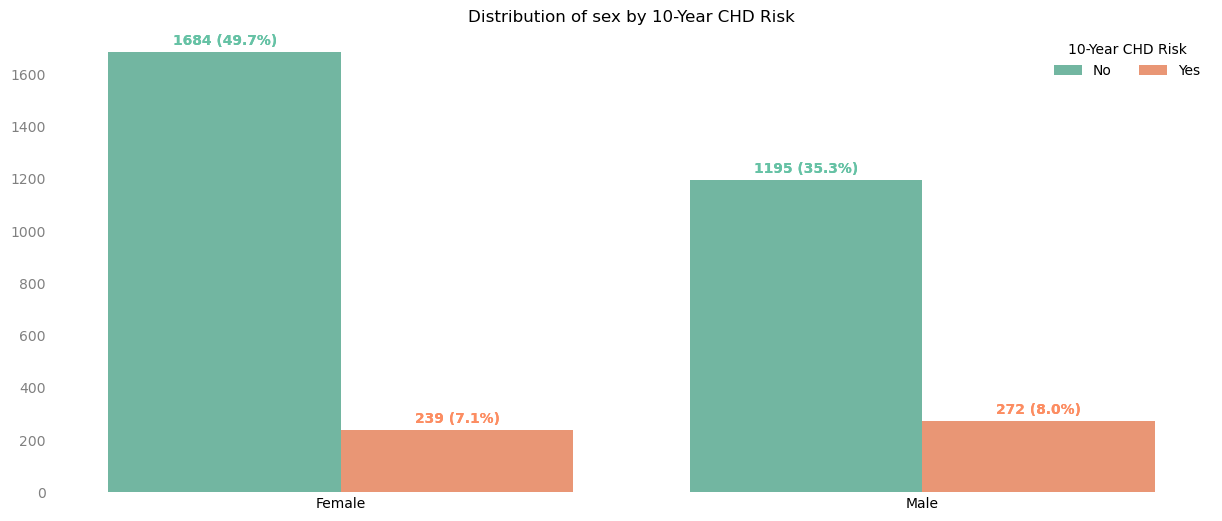

In [17]:
countplot_style(
    data=df,
    x_column=df["sex"],
    hue_column_name="TenYearCHD",
    title="Distribution of sex by 10-Year CHD Risk",
    legend_title="10-Year CHD Risk" 
)

In charts it's visible that even though there is a higher representation of females in the dataset, males have higher count of people with a CHD risk. This means it may be a valuable factor to consider. However, here representation of groups is also a little bit imbalanced as sample of females is higher. What is good that it's not by much.  

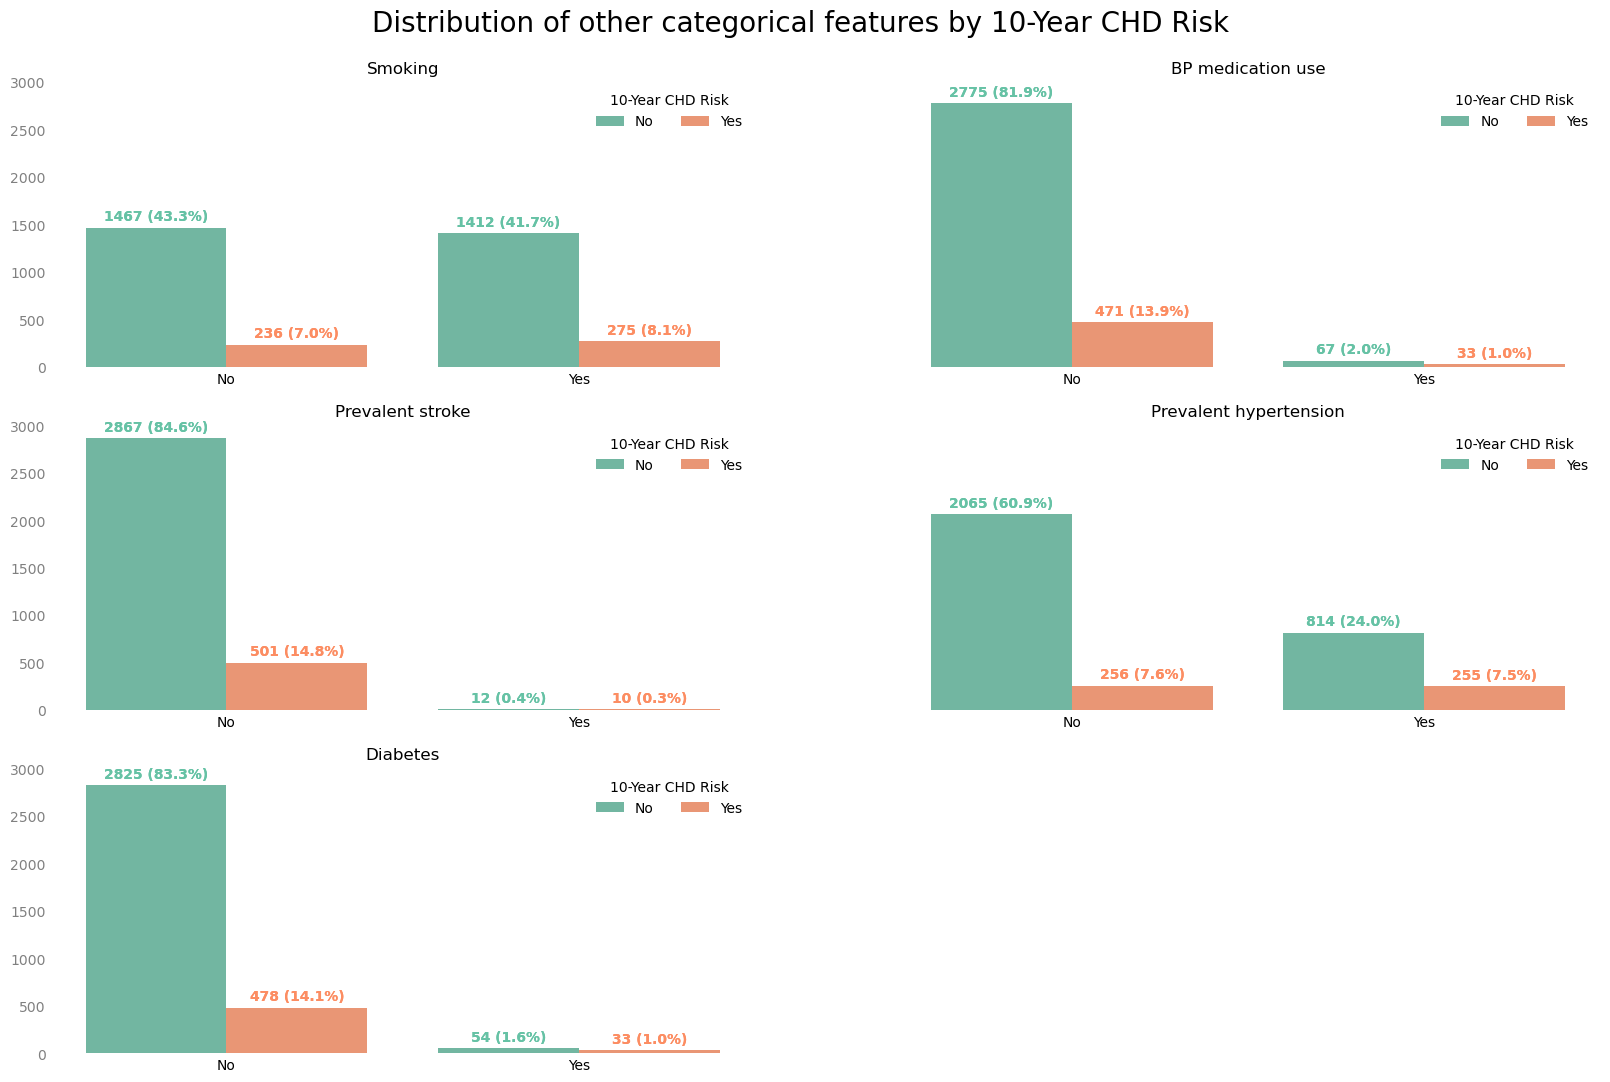

In [18]:
fig, axes = plt.subplots(
    3, 
    2, 
    figsize=(20, 12), 
    sharey=True
)

axes = axes.flatten()

countplot_style(
    data=df,
    x_column="is_smoking",
    hue_column_name="TenYearCHD",
    title="Smoking",
    legend_title="10-Year CHD Risk",
    ax=axes[0]
)

countplot_style(
    data=df,
    x_column="BPMeds",
    hue_column_name="TenYearCHD",
    title="BP medication use",
    legend_title="10-Year CHD Risk",
    ax=axes[1]
)


countplot_style(
    data=df,
    x_column="prevalentStroke",
    hue_column_name="TenYearCHD",
    title="Prevalent stroke",
    legend_title="10-Year CHD Risk",
    ax=axes[2]
)

countplot_style(
    data=df,
    x_column="prevalentHyp",
    hue_column_name="TenYearCHD",
    title="Prevalent hypertension",
    legend_title="10-Year CHD Risk",
    ax=axes[3]
)

countplot_style(
    data=df,
    x_column="diabetes",
    hue_column_name="TenYearCHD",
    title="Diabetes",
    legend_title="10-Year CHD Risk",
    ax=axes[4]
)

axes[5].set_visible(False)

plt.suptitle(
    "Distribution of other categorical features by 10-Year CHD Risk", 
    fontsize=20
)

plt.subplots_adjust(top=0.92)

plt.show()

Here it is visible that smoking has an almost 50/50 split of population. It overrepresents smoking as [in USA more currently](https://www.cdc.gov/tobacco/campaign/tips/resources/data/cigarette-smoking-in-united-states.html) only about 11.6% smoke. Additionally, other categories have quite low representations of their positive features, especially being prevalent to have a stroke or using BP medication. This could affect the model's ability on predicting outcomes related to less common features. 

Additionally, people who use BP medication, are prevalent to stroke or have diabetes, proportionally seen to have higher chance of CHD risk. That is also visible prevalence of hypertension, but a bit less. This means that these variables, may be important predictors for the model, but have very small representations. 

#### Numeric features

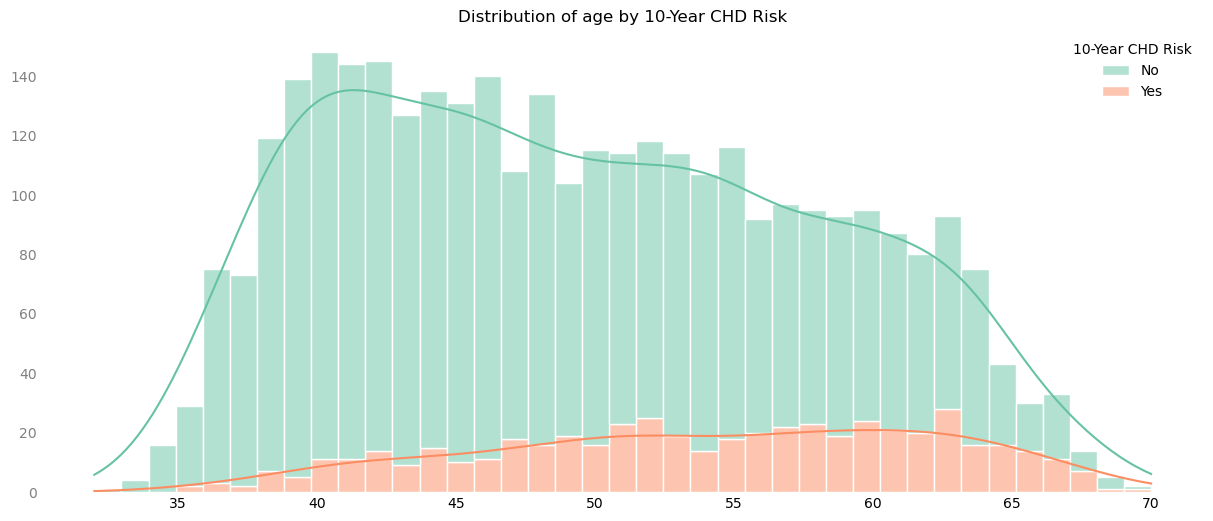

In [19]:
histplot_style(
    data=df,
    x_column="age", 
    hue_column_name="TenYearCHD",
    title="Distribution of age by 10-Year CHD Risk",
    legend_title="10-Year CHD Risk",
    bins = 39
)

From this distribution it's visible that age might correlate with CHD risk. However, ages younger than 40 have less representative distribution, even though general population does have many people in younger age group. It means that model will have limitations in this area.

With older people, there are no records after age of 70 and very small amount after age of 65. However, even though with age population decreases, [in Statista](https://www.statista.com/statistics/241488/population-of-the-us-by-sex-and-age/) it visible that ages 65-69 still make a relatively big part of population (around 6%) and we are still many people alive after age of 70. This means that this group also is underrepresented in dataset. 

It's important to also remember that some other features may correlate with each other as well. Later on will need to check if age correlates other features to access if there is multicollinearity which could pose issues to the model. That's because after a brief search, we can see ["over 70% of all strokes occur above the age of 65"](https://pmc.ncbi.nlm.nih.gov/articles/PMC3006180/). 

In [20]:
numeric_float_columns = [col for col in df.columns if df[col].dtype == "float64"]
numeric_float_columns

['cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

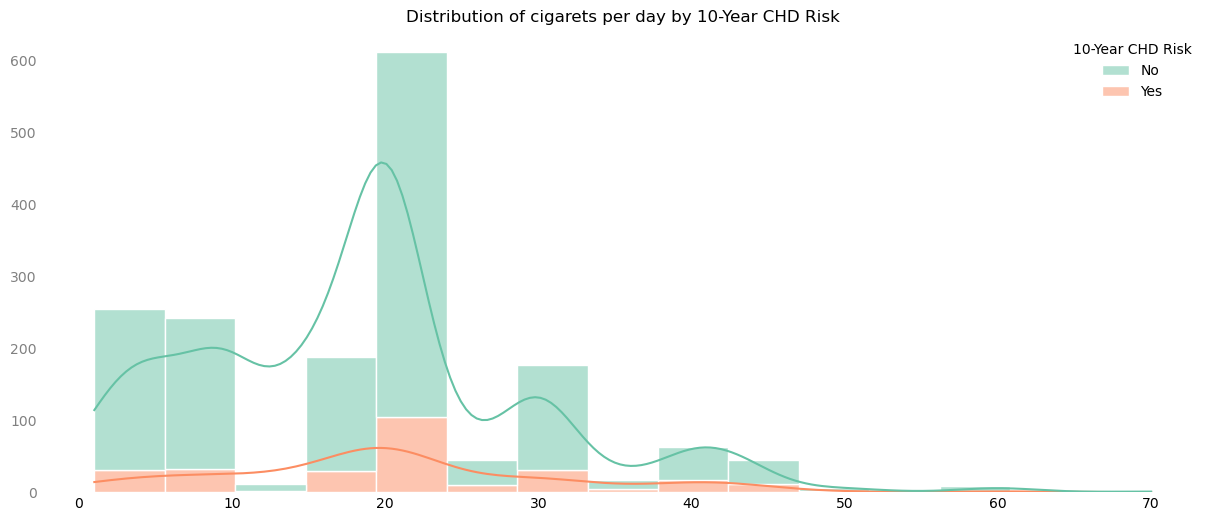

In [21]:
histplot_style(
    data=df[df["cigsPerDay"] != 0],
    x_column="cigsPerDay",
    hue_column_name="TenYearCHD",
    title="Distribution of cigarets per day by 10-Year CHD Risk",
    legend_title="10-Year CHD Risk",
    bins=15
)

In [22]:
none_smokers = df["cigsPerDay"][df["cigsPerDay"] == 0].count() / len(df) * 100   
print(f"None smokers: {none_smokers:.2f}%")

None smokers: 50.24%


Because from previously it was visible around 50% of dataset's participants were non smokers, in chart I chose to visualize those who smoke, to more clearly see patterns in their population. 

From the histogram it's visible that the ones who smoke, most use around 20 cigarets per day ore more. However, from [more current data provided by American lung association](https://www.lung.org/research/trends-in-lung-disease/tobacco-trends-brief/overall-smoking-trends) we can see that smoking rates decreased and currently most smoke 15 or less. 

Additionally, in current day alternative products like vapes or IQOS are becoming more popular but are absent from this study.

Lastly, since there is another variable for identifying if person is smoking or not, it may have multicollinearity issues with this one which need to be checked later on. 

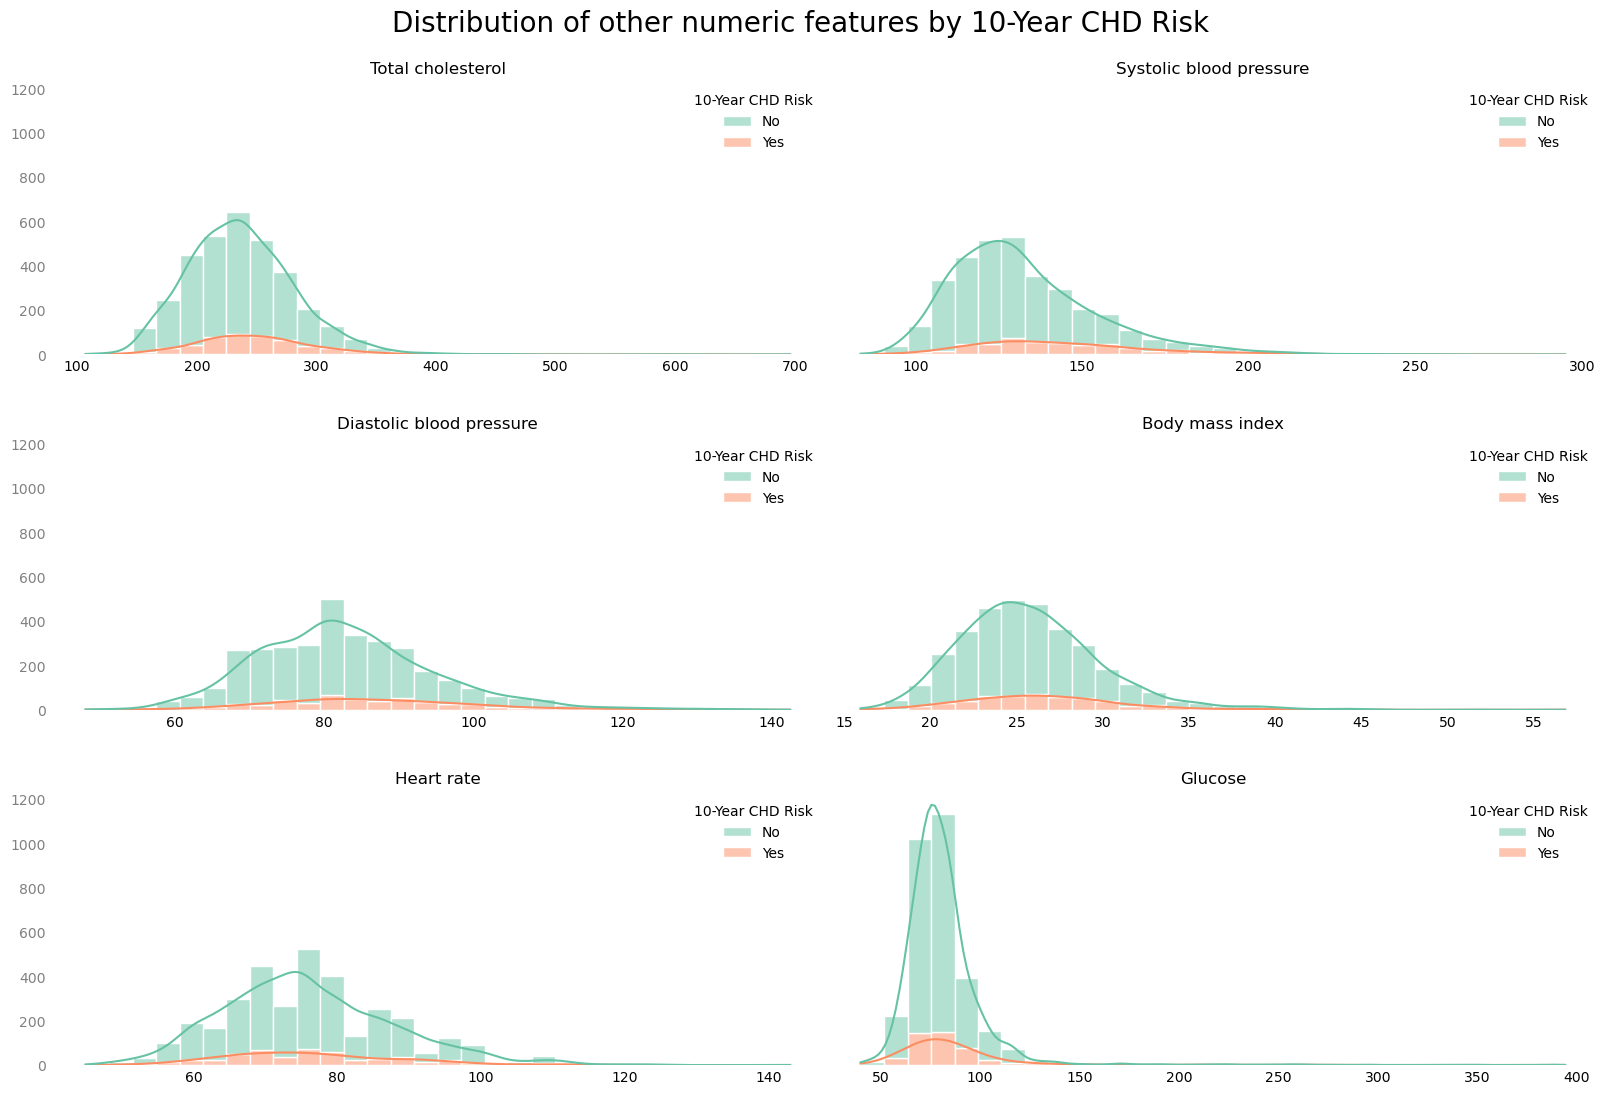

In [23]:
fig, axes = plt.subplots(
    3, 
    2, 
    figsize=(20, 12), 
    sharey=True
)

axes = axes.flatten()

histplot_style(
    data=df,
    x_column="totChol",
    hue_column_name="TenYearCHD",
    title="Total cholesterol",
    legend_title="10-Year CHD Risk",
    bins=30,
    ax=axes[0]
)

histplot_style(
    data=df,
    x_column="sysBP",
    hue_column_name="TenYearCHD",
    title="Systolic blood pressure",
    legend_title="10-Year CHD Risk",
    bins=30,
    ax=axes[1]
)

histplot_style(
    data=df,
    x_column="diaBP",
    hue_column_name="TenYearCHD",
    title="Diastolic blood pressure",
    legend_title="10-Year CHD Risk",
    bins=30,
    ax=axes[2]
)

histplot_style(
    data=df,
    x_column="BMI",
    hue_column_name="TenYearCHD",
    title="Body mass index",
    legend_title="10-Year CHD Risk",
    bins=30,
    ax=axes[3]
)

histplot_style(
    data=df,
    x_column="heartRate",
    hue_column_name="TenYearCHD",
    title="Heart rate",
    legend_title="10-Year CHD Risk",
    bins=30,
    ax=axes[4]
)

histplot_style(
    data=df,
    x_column="glucose",
    hue_column_name="TenYearCHD",
    title="Glucose",
    legend_title="10-Year CHD Risk",
    bins=30,
    ax=axes[5]
)

plt.suptitle(
    "Distribution of other numeric features by 10-Year CHD Risk", 
    fontsize=20
)

fig.subplots_adjust(
    top=0.92, 
    bottom=0.1, 
    wspace=0, 
    hspace=0.3
)

plt.show()

From charts it's visible that most share normal distribution, for both positive and negative CHD risk cases. However, it seems that they also have outliers on the higher end. For example, for glucose, according to [National Library of Medicine](https://pmc.ncbi.nlm.nih.gov/articles/PMC6169544/) it is possible when having conditions like diabetes. Other outliers are valid data points as well as it was determined during initial data cleaning step, by reviewing study documentation and minimum and maximum observations. 

Presence of natural outliers will need to take it into account when choosing scaling/transformation techniques. Also, features like glucose will need to be kept in mind same as before, as it could introduce multicollinearity with categorical variables like diabetes later on.

#### Key takeaways

- **Stratified Splitting for Imbalanced Data.** Given the class imbalance observed in the dataset, it’s important to use stratified splitting during the train-test split to ensure that the proportions of the target variable are consistent across both subsets.
- **Skewed Feature transformation.** Features such as glucose are positively skewed. Applying appropriate transformation techniques, such as log transformation, will be necessary to improve the performance of the model.
- **Multicollinearity Check.** After encoding categorical variables, it's crucial to assess multicollinearity, as some features may be correlated (e.g., diabetes and glucose). This could impact model stability and should be addressed, potentially through techniques like feature selection.
- **Class Imbalance Handling.** Given the imbalanced distribution of target classes, I may need to adjust the model's decision threshold and apply class weights to ensure the minority class is adequately represented.
- **Outdated Distributions.** Certain features, such as education level and smoking habits, may not reflect current trends (possible Concept Drift). This is important to consider, as these outdated distributions could negatively affect model accuracy and generalization.
- **Alternative Performance Metrics.** Since accuracy is not a reliable metric for imbalanced datasets, metrics like recall, F2-score, and ROC-AUC, log loss should be prioritized for evaluating the model's performance, especially in terms of how it handles the minority class.

### Splitting dataset

To make sure train and test data is split using stratification of not only target variable, but also taking features into account, custom function was defined to help with that. It combines the values of selected categorical columns (features) into a new variable, ensuring that the stratification considers both the target and feature distributions. This results in a split where the proportions of target and feature combinations are preserved across both the training and test datasets, providing a more representative split for imbalanced data. 

In [24]:
def multi_stratified_split(df, start_cols, test_size=0.2, random_state=42):

    df["combined_strat"] = df[start_cols].apply(
        lambda x: "_".join(x.astype(str)), 
        axis=1
    )
    
    train_idx, test_idx = train_test_split(
        np.arange(len(df)),
        test_size=test_size,
        stratify=df["combined_strat"],
        random_state=random_state
    )
    
    train_data = df.iloc[train_idx].drop("combined_strat", axis=1)
    test_data = df.iloc[test_idx].drop("combined_strat", axis=1)
    
    return train_data, test_data

Because some of the groups have very few values, together with target variable, which is the most important, the smallest feature group was chosen - Prevalence of stroke. It had a total of only 22 positive values. More columns could not be included because they ended up creating too many unique combinations. To ensure this stratification was enough, below distributions of splits can be compared between training and test sets. 

In [25]:
train, test = multi_stratified_split(
    df = df, 
    start_cols=[
    "prevalentStroke",
    "TenYearCHD"
    ]
)

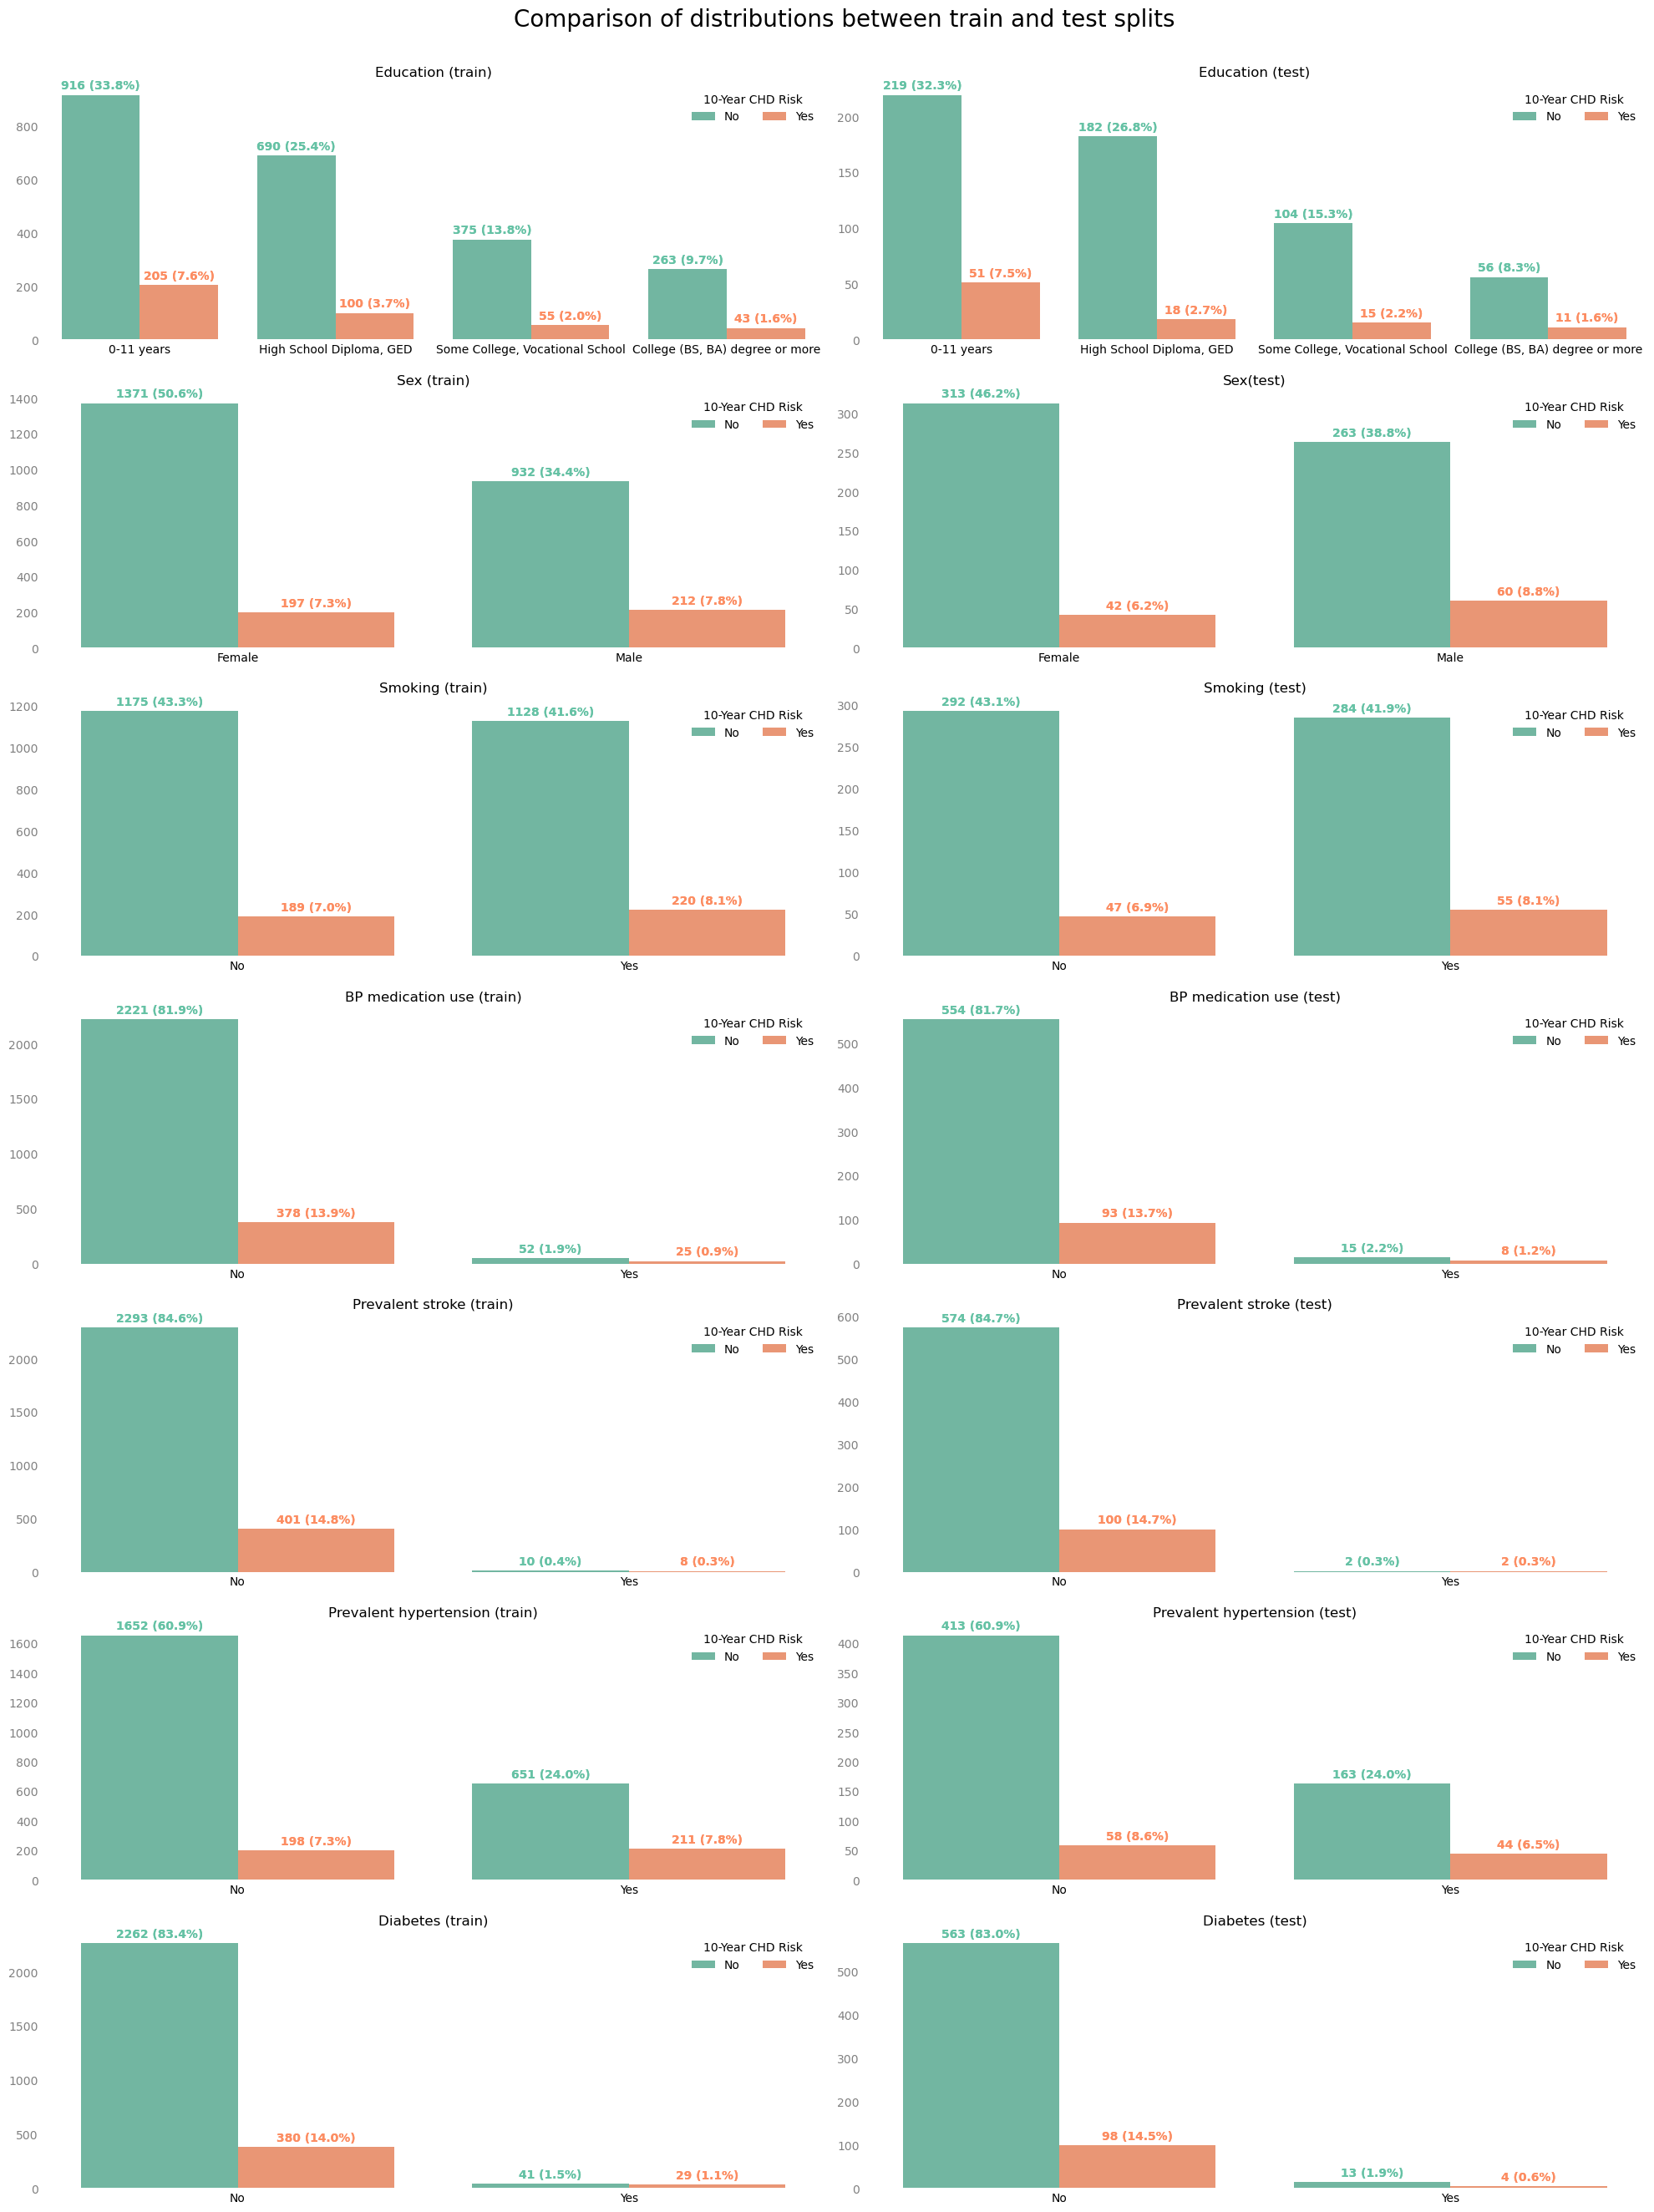

In [26]:
fig, axes = plt.subplots(
    7, 
    2, 
    figsize=(24, 30)
)

axes = axes.flatten()

countplot_style(
    data=train,
    x_column="education",
    hue_column_name="TenYearCHD",
    title="Education (train)",
    legend_title="10-Year CHD Risk",
    ax=axes[0]
)

countplot_style(
    data=test,
    x_column="education",
    hue_column_name="TenYearCHD",
    title="Education (test)",
    legend_title="10-Year CHD Risk",
    ax=axes[1]
)

countplot_style(
    data=train,
    x_column="sex",
    hue_column_name="TenYearCHD",
    title="Sex (train)",
    legend_title="10-Year CHD Risk",
    ax=axes[2]
)

countplot_style(
    data=test,
    x_column="sex",
    hue_column_name="TenYearCHD",
    title="Sex(test)",
    legend_title="10-Year CHD Risk",
    ax=axes[3]
)

countplot_style(
    data=train,
    x_column="is_smoking",
    hue_column_name="TenYearCHD",
    title="Smoking (train)",
    legend_title="10-Year CHD Risk",
    ax=axes[4]
)

countplot_style(
    data=test,
    x_column="is_smoking",
    hue_column_name="TenYearCHD",
    title="Smoking (test)",
    legend_title="10-Year CHD Risk",
    ax=axes[5]
)

countplot_style(
    data=train,
    x_column="BPMeds",
    hue_column_name="TenYearCHD",
    title="BP medication use (train)",
    legend_title="10-Year CHD Risk",
    ax=axes[6]
)

countplot_style(
    data=test,
    x_column="BPMeds",
    hue_column_name="TenYearCHD",
    title="BP medication use (test)",
    legend_title="10-Year CHD Risk",
    ax=axes[7]
)

countplot_style(
    data=train,
    x_column="prevalentStroke",
    hue_column_name="TenYearCHD",
    title="Prevalent stroke (train)",
    legend_title="10-Year CHD Risk",
    ax=axes[8]
)

countplot_style(
    data=test,
    x_column="prevalentStroke",
    hue_column_name="TenYearCHD",
    title="Prevalent stroke (test)",
    legend_title="10-Year CHD Risk",
    ax=axes[9]
)

countplot_style(
    data=train,
    x_column="prevalentHyp",
    hue_column_name="TenYearCHD",
    title="Prevalent hypertension (train)",
    legend_title="10-Year CHD Risk",
    ax=axes[10]
)

countplot_style(
    data=test,
    x_column="prevalentHyp",
    hue_column_name="TenYearCHD",
    title="Prevalent hypertension (test)",
    legend_title="10-Year CHD Risk",
    ax=axes[11]
)

countplot_style(
    data=train,
    x_column="diabetes",
    hue_column_name="TenYearCHD",
    title="Diabetes (train)",
    legend_title="10-Year CHD Risk",
    ax=axes[12]
)

countplot_style(
    data=test,
    x_column="diabetes",
    hue_column_name="TenYearCHD",
    title="Diabetes (test)",
    legend_title="10-Year CHD Risk",
    ax=axes[13]
)


plt.suptitle("Comparison of distributions between train and test splits", fontsize=20)

plt.subplots_adjust(
    top=0.95, 
    wspace=0.05, 
    left=0.1
)

plt.show()

There are some differences in distribution but they have stayed quite similar. All categories have remained in both sets, which was important to ensure accurate model training. 

### Creating pipeline to address data issues

The issues that need to be addressed are:
1. Positively skewed numeric columns with outliers. 
2. Scaling numerical variables to be on the same scale. 
3. Encoding categorical data. 
4. Imputing missing values. 

#### Outliers

First, created custom function for violin plot style.

In [27]:
def violinplot_style(data, x_column, hue_column_name, title, ax=None):  
    
    if ax is None:
        fig, ax = plt.subplots(
             figsize=(15, 6)
        )

    n_hue_categories = len(data[hue_column_name].unique())
    
    sns.violinplot(
        data=data,
        hue=hue_column_name,  
        x=x_column,        
        palette=sns.color_palette(
            "Set2", 
            n_colors=n_hue_categories
        ),
        inner="box",        
        cut=0,
        y=hue_column_name,
        inner_kws=dict(
            box_width=15, 
            whis_width=2, 
            color=".8"
        ),         
        ax=ax  
    )

    for violin in ax.collections:
            if isinstance(violin, matplotlib.collections.PolyCollection):
                violin.set_edgecolor(".8")

    ax.set_title(title)

    sns.despine(
        left=True,
        bottom=True,
        ax=ax
    )

    ax.set(
        xlabel=None,
        ylabel=None
    )

    ax.tick_params(
        axis="both",
        which="both",
        length=0
    )

    ax.tick_params(
        axis="y",
        labelcolor="gray"
    )

    if ax is None:
        plt.show()

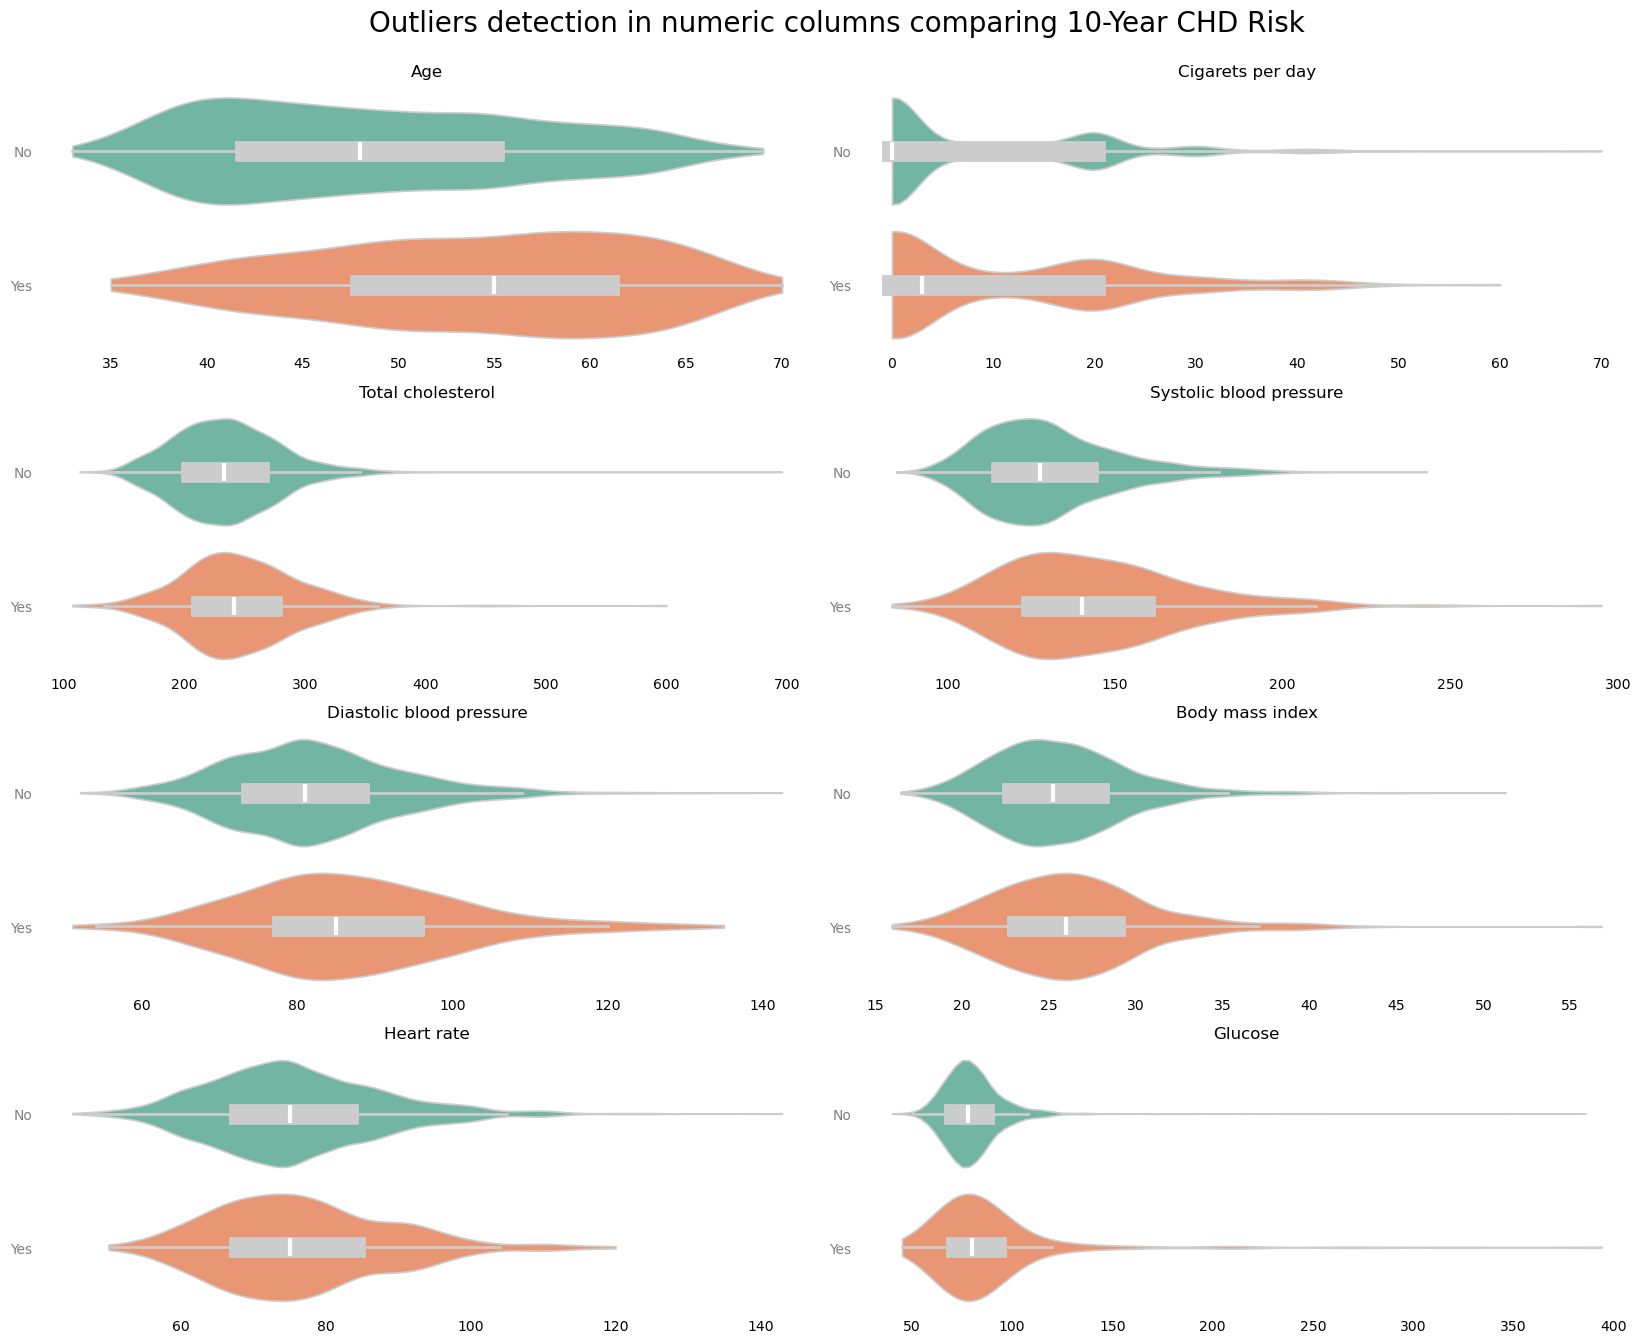

In [28]:
fig, axes = plt.subplots(
    4, 
    2, 
    figsize=(20, 15)
)

axes = axes.flatten()

violinplot_style(
    data=train,
    x_column="age",
    hue_column_name="TenYearCHD",
    title="Age",
    ax=axes[0]
)

violinplot_style(
    data=train,
    x_column="cigsPerDay",
    hue_column_name="TenYearCHD",
    title="Cigarets per day",
    ax=axes[1]
)

violinplot_style(
    data=train,
    x_column="totChol",
    hue_column_name="TenYearCHD",
    title="Total cholesterol",
    ax=axes[2]
)

violinplot_style(
    data=train,
    x_column="sysBP",
    hue_column_name="TenYearCHD",
    title="Systolic blood pressure",
    ax=axes[3]
)

violinplot_style(
    data=train,
    x_column="diaBP",
    hue_column_name="TenYearCHD",
    title="Diastolic blood pressure",
    ax=axes[4]
)

violinplot_style(
    data=train,
    x_column="BMI",
    hue_column_name="TenYearCHD",
    title="Body mass index",
    ax=axes[5]
)

violinplot_style(
    data=train,
    x_column="heartRate",
    hue_column_name="TenYearCHD",
    title="Heart rate",
    ax=axes[6]
)

violinplot_style(
    data=train,
    x_column="glucose",
    hue_column_name="TenYearCHD",
    title="Glucose",
    ax=axes[7]
)

plt.suptitle(
    "Outliers detection in numeric columns comparing 10-Year CHD Risk", 
    fontsize=20
)

plt.subplots_adjust(
    top=0.93, 
    wspace=0.05, 
    left=0.1
)

plt.show()

In [29]:
df[numeric_float_columns].skew().sort_values(ascending=False)

glucose       6.144390
cigsPerDay    1.223005
sysBP         1.175837
BMI           1.022252
totChol       0.940636
diaBP         0.718173
heartRate     0.676490
dtype: float64

It is visible that most severe outliers are present glucose column. Due to this, log transformation will be used on this feature when training the model.

#### Scaling

Scaling method which will be used is StandardScaler. That's because most distributions are already close to normal as was seen in previous histograms. Also, log transformation will take care of outlier in most skewed one - glucose. Since there is already function for it which can be used in pipeline, there is no need to define additional one. 

#### Encoding

When it comes to encoding categorical columns, at most they have 4 unique values (education), thus simple encoding techniques can be used. Since education is an ordinal category, for it OrdinalEncoder will be used. For all else - OneHotEncoder. For OneHotEncoder, since it creates seperate column for each value, will need to add condition of dropping first one. That's because otherwise it can introduce multicollinearity of so called "dummy variable trap".

#### Imputation

First, will display the missing values present in data. 


In [30]:
columns_with_na = pd.DataFrame(
    train
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

columns_with_na = columns_with_na.rename(columns={0: "count"})
columns_with_na["percentage"] = (
    (train.isnull().sum() / len(train)) 
    * 100
).round(2)

columns_with_na = columns_with_na[columns_with_na["percentage"] > 0]

columns_with_na

,count,percentage
glucose,251,9.26
education,65,2.40
BPMeds,36,1.33
totChol,29,1.07
cigsPerDay,16,0.59
BMI,12,0.44


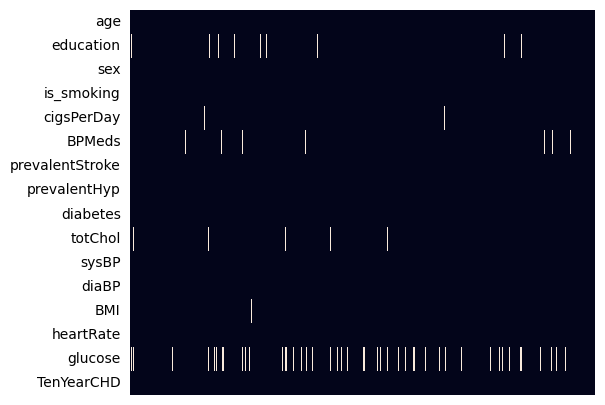

In [31]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    train.isnull().T, 
    xticklabels=False,
    cbar=False
)

plt.xlabel("")

plt.tick_params(left=False) 

plt.show()

It is visible that most missing values are in glucose column. However, this group is connected to having diabetes. Same for features like cigsPerDay being connected to is_smoking. To make sure these connections are taken into account, I will use KNNImputer. It does it by using Euclidean distance between rows based on other features. The number of neighbors used at first to be tested will be 5. A smaller value may be more sensitive to noise, while a larger value may oversmooth the data, thus it can be tweaked while validating later on. 

#### Building pipeline

To make sure all these techniques are easily reproducible on training and test sets, I will build a pipeline which will be able to handle all of them in same order. 

1. Separating target variable from feature ones. 
2. Applying log transformation on previously defined skewed variables. 
3. Manually converting BPMeds to numeric instead of using dummy variables, because it's only one with missing values from binary ones and OneHotEncoder cannot handle them in a way which would allow them to be used with KNNImputer easily.
4. Defining numeric and nominal data columns. Also, defining order of values for ordinal variable - education. 
5. Defining rounding transformation function to be used after KNNImputer on categorical variables. 
6. Defining separate pipelines for each data type. That is needed, because column transformer does not follow a sequence, thus those have to be defined separately on:
    - Numeric columns will be scaled and imputed. 
    - Education column will be encoded using OrdinalEncoder, imputed and rounded to to keep encoding consistency. 
    - Nominal columns will be encoded using OneHotEncoder.
    - BPMeds categorical column was manually encoded before, thus will be imputed and rounded to keep encoding consistency.
7. Applying column transformed on each different category. 
8. Setting up final pipeline with logistic regression settings tweaked. Using:
    - "balanced" weight should help with class imbalance of the dataset. 
    - Using 1000 instead of default 100 max iterations to ensure that the solver has sufficient iterations to find a good fit.

In [32]:
# 1
y_train = train["TenYearCHD"]

x_train = train.drop(columns=["TenYearCHD"])

# 2
x_train["glucose"] = np.log(x_train["glucose"])

# 3
x_train["BPMeds"] = x_train["BPMeds"].map({
    "No":0, 
    "Yes":1}
).astype("Int64")

# 4
numeric_columns = [
    col for col in x_train.columns 
    if x_train[col].dtype in ["float64", "int64"]
]

nominal_columns = [
    col for col in x_train.columns 
    if col not in ["education", "TenYearCHD", "BPMeds"] 
    and x_train[col].dtype.name == "category"
]

education_order = [
        "0-11 years",
        "High School Diploma, GED",
        "Some College, Vocational School",
        "College (BS, BA) degree or more",
        np.nan
    ]

def pipeline_transformer(numeric_columns, nominal_columns, education_order):
    # 5 
    round_transformer = FunctionTransformer(
        func=lambda X: np.rint(X),
        validate=False
    )

    # 6
    numeric_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("imputer", KNNImputer(n_neighbors=5))  
    ])

    education_pipeline = Pipeline([
        ("ordinal",
            OrdinalEncoder(
                categories=[education_order],       
                encoded_missing_value=np.nan,
                handle_unknown="use_encoded_value",  
                unknown_value=-1      
            )
        ),
        ("imputer", KNNImputer(n_neighbors=5)),
        ("rounder", round_transformer)
    ])

    nominal_pipeline = Pipeline([
        ("onehot", OneHotEncoder(
            drop="first", 
            sparse_output=False
        ))
    ])

    BPMeds_pipeline = Pipeline([
        ("imputer", KNNImputer(n_neighbors=5)),
        ("rounder", round_transformer) 
    ])

    # 7
    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_columns),
        ("edu", education_pipeline, ["education"]),
        ("nominal", nominal_pipeline, nominal_columns),
        ("meds", BPMeds_pipeline, ["BPMeds"])
    ])

    # 8
    return Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            class_weight="balanced", 
            max_iter=1000
        ))
    ])

Now transforming the x_train variables. 

In [33]:
pipeline_instance = pipeline_transformer(
    numeric_columns, 
    nominal_columns, 
    education_order
)

preprocessor = pipeline_instance.named_steps["preprocessor"]

X_train_transformed = preprocessor.fit_transform(x_train)

Next is validating if pipeline x transformation worked as expected. First, will put all features back into a table. For that will need to recover column names and then create pd.DataFrame.

In [34]:
ct = pipeline_instance.named_steps["preprocessor"]

numeric_feature_names = numeric_columns

education_feature_names = ["education_ordinal"]

BPMeds_feature_names = ["BPMeds_Yes"]

nominal_subpipeline = ct.named_transformers_["nominal"]
ohe = nominal_subpipeline.named_steps["onehot"]
nominal_feature_names = ohe.get_feature_names_out(nominal_columns)

all_feature_names = (
    list(numeric_feature_names)
    + education_feature_names
    + list(nominal_feature_names)
    + BPMeds_feature_names
)

x_train_transformed = pd.DataFrame(
    X_train_transformed, 
    columns=all_feature_names, 
    index=x_train.index
)

x_train_transformed.head()

,age,cigsPerDay,totChol,sysBP,diaBP,BMI,heartRate,glucose,education_ordinal,sex_Male,is_smoking_Yes,prevalentStroke_Yes,prevalentHyp_Yes,diabetes_Yes,BPMeds_Yes
id,,,,,,,,,,,,,,,
851,2.036391,-0.764511,0.244594,3.627079,1.834478,-0.686229,1.162797,0.932273,0.0,0.0,0.0,0.0,1.0,0.0,0.0
937,-0.639332,-0.335111,0.619076,-1.009720,-0.404188,-1.175738,-1.320148,-0.786301,3.0,0.0,1.0,0.0,0.0,0.0,0.0
3259,0.407690,-0.764511,1.103700,-0.479800,-0.238361,0.121582,0.086854,0.293331,1.0,1.0,0.0,0.0,1.0,0.0,0.0
2046,2.036391,-0.678631,0.112424,1.728199,0.093293,-1.433755,-0.492500,1.584566,2.0,0.0,1.0,0.0,1.0,0.0,0.0
2045,0.640362,-0.764511,-1.363475,-1.120120,-1.482065,-1.346946,-0.658029,-0.060848,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [35]:
x_train.head()

,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
id,,,,,,,,,,,,,,,
851,67,0-11 years,Female,No,0.0,0,No,Yes,No,248.0,215.0,105.0,22.91,90.0,4.574711
937,44,"College (BS, BA) degree or more",Female,Yes,5.0,0,No,No,No,265.0,110.0,78.0,20.88,60.0,4.219508
3259,53,"High School Diploma, GED",Male,No,0.0,0,No,Yes,No,287.0,122.0,80.0,26.26,77.0,4.442651
2046,67,"Some College, Vocational School",Female,Yes,1.0,0,No,Yes,No,242.0,172.0,84.0,19.81,70.0,4.709530
2045,55,"High School Diploma, GED",Female,No,0.0,0,No,No,No,175.0,107.5,65.0,20.17,68.0,4.369448


In [36]:
x_train_transformed["BPMeds_Yes"].value_counts()

BPMeds_Yes
0.0    2635
1.0      77
Name: count, dtype: int64

In [37]:
x_train_transformed["education_ordinal"].value_counts()

education_ordinal
0.0    1121
1.0     855
2.0     430
3.0     306
Name: count, dtype: int64

In [38]:
x_train_transformed.isnull().any().any()

np.False_

In [39]:
train_transformed = pd.concat(
    [x_train_transformed, y_train], 
    axis=1
)

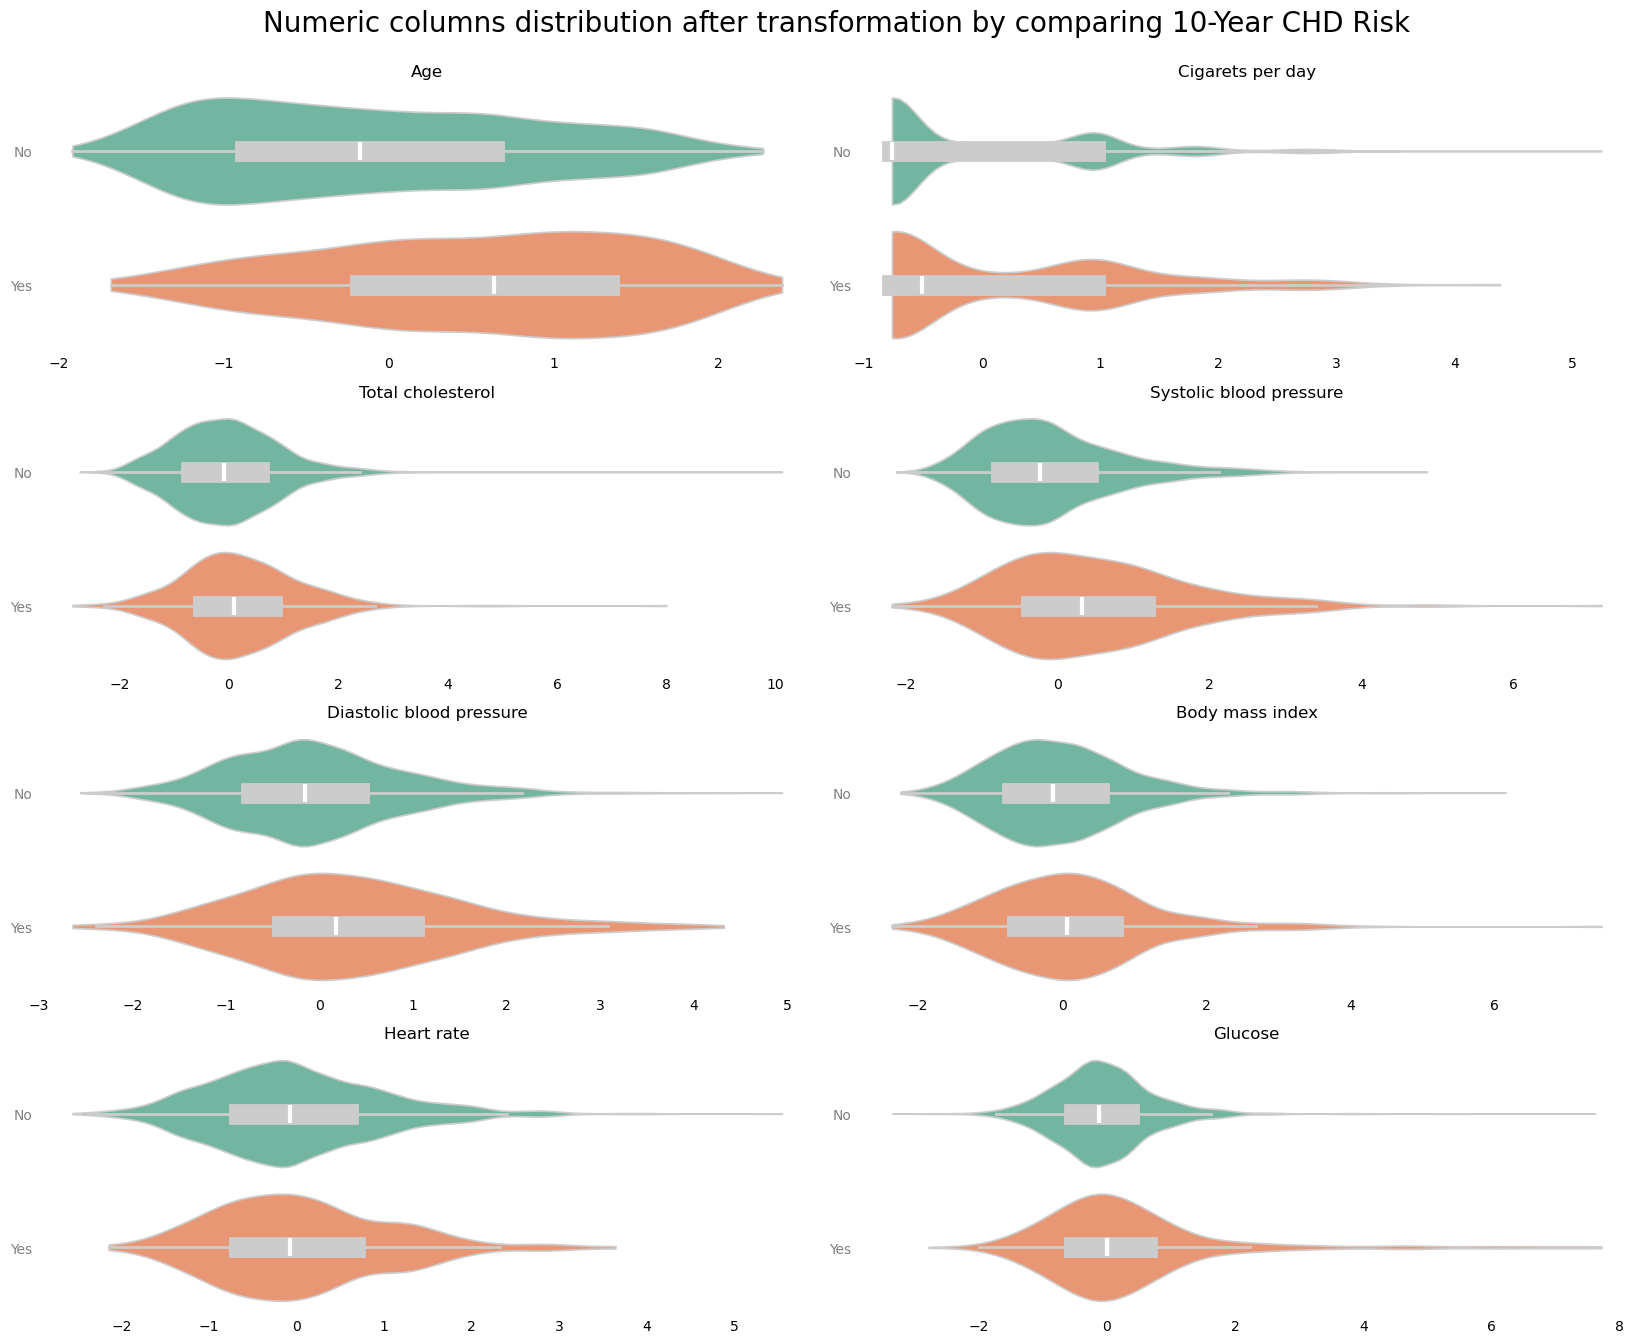

In [40]:
fig, axes = plt.subplots(
    4, 
    2, 
    figsize=(20, 15)
)

axes = axes.flatten()

violinplot_style(
    data=train_transformed,
    x_column="age",
    hue_column_name="TenYearCHD",
    title="Age",
    ax=axes[0]
)

violinplot_style(
    data=train_transformed,
    x_column="cigsPerDay",
    hue_column_name="TenYearCHD",
    title="Cigarets per day",
    ax=axes[1]
)

violinplot_style(
    data=train_transformed,
    x_column="totChol",
    hue_column_name="TenYearCHD",
    title="Total cholesterol",
    ax=axes[2]
)

violinplot_style(
    data=train_transformed,
    x_column="sysBP",
    hue_column_name="TenYearCHD",
    title="Systolic blood pressure",
    ax=axes[3]
)

violinplot_style(
    data=train_transformed,
    x_column="diaBP",
    hue_column_name="TenYearCHD",
    title="Diastolic blood pressure",
    ax=axes[4]
)

violinplot_style(
    data=train_transformed,
    x_column="BMI",
    hue_column_name="TenYearCHD",
    title="Body mass index",
    ax=axes[5]
)

violinplot_style(
    data=train_transformed,
    x_column="heartRate",
    hue_column_name="TenYearCHD",
    title="Heart rate",
    ax=axes[6]
)

violinplot_style(
    data=train_transformed,
    x_column="glucose",
    hue_column_name="TenYearCHD",
    title="Glucose",
    ax=axes[7]
)

plt.suptitle("Numeric columns distribution after transformation by comparing 10-Year CHD Risk", fontsize=20)

plt.subplots_adjust(
    top=0.93, 
    wspace=0.05, 
    left=0.1
)

plt.show()

In [41]:
train_transformed[numeric_float_columns].skew().sort_values(ascending=False)

glucose       2.304675
cigsPerDay    1.237941
sysBP         1.181446
BMI           1.062138
totChol       1.019586
diaBP         0.705418
heartRate     0.702578
dtype: float64

Because logistic regression does not require it's features to have very good normal distribution, this should be okay. However, will need to keep an eye if values on higher end will be severe enough to affect the model.

### Variable selection

Before proceeding with fitting the model, first need to inspect variables for multicollinearity. To determine that, will use VIF score calculation and correlation matrix to help visualize what correlates with what. 

According to [Statistics how to](https://www.statisticshowto.com/variance-inflation-factor/):
- 1 = not correlated.
- Between 1 and 5 = moderately correlated.
- Greater than 5 = highly correlated.

However, it mentions that some "authors suggest a more conservative level of 2.5 or above".

In [42]:
def vif_scoring(x_train_transformed): 
    vif_data = pd.DataFrame()

    vif_data["Feature"] = x_train_transformed.columns

    vif_scores = []

    for col in range(len(x_train_transformed.columns)):
        vif = variance_inflation_factor(
            x_train_transformed.values, 
            col
        )
        vif_scores.append(vif)
        
    vif_data["VIF"] = vif_scores

    return vif_data.sort_values(
        by="VIF", 
        ascending=False
    ).reset_index(drop=True)

vif_scoring(x_train_transformed)

,Feature,VIF
0,sysBP,3.801956
1,is_smoking_Yes,2.920126
2,diaBP,2.888148
3,prevalentHyp_Yes,2.647817
4,cigsPerDay,1.855364
5,sex_Male,1.783728
6,education_ordinal,1.744365
7,age,1.403214
8,diabetes_Yes,1.386002
9,glucose,1.385075


It's visible that having prevalent hypertension, smoking, diastolic and systolic blood pressure do have VIF scores above 2.5. To help understand where it is coming from, will display correlation matrix next. 

In [94]:
def plot_correlation_matrix(encoded_data, columns_to_exclude=None, figsize=(12, 10)):

    if columns_to_exclude is None:
        columns_to_exclude = []
    
    columns_to_include = [
        col for col in encoded_data.columns 
        if col not in columns_to_exclude
    ]
    corr_matrix = encoded_data[columns_to_include].corr()
    
    tick_positions = [-1, -0.7, -0.5, -0.3, 0, 0.3, 0.5, 0.7, 1]

    tick_labels = [
        "-1 = Perfect Negative",
        "-0.7 = Strong Negative",
        "-0.5 = Moderate Negative",
        "-0.3 = Weak Negative",
        "0 = No Correlation",
        "0.3 = Weak Positive",
        "0.5 = Moderate Positive",
        "0.7 = Strong Positive",
        "1 = Perfect Positive",
    ]
    
    set2_colors = sns.color_palette("Set2")[:2]

    custom_cmap = LinearSegmentedColormap.from_list(
        "custom", [
            set2_colors[1],
            "white", 
            set2_colors[0]
            ]
        )

    # Create the plot
    plt.figure(figsize=figsize)
    heatmap = sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap=custom_cmap,
        linewidths=0.5,
        vmin=-1,
        vmax=1,
        cbar_kws={"ticks": tick_positions}
    )
    
    colorbar = heatmap.collections[0].colorbar
    colorbar.set_ticks(tick_positions)
    colorbar.set_ticklabels(tick_labels)
    
    plt.title("Correlation Matrix of feature variables")
    plt.show()

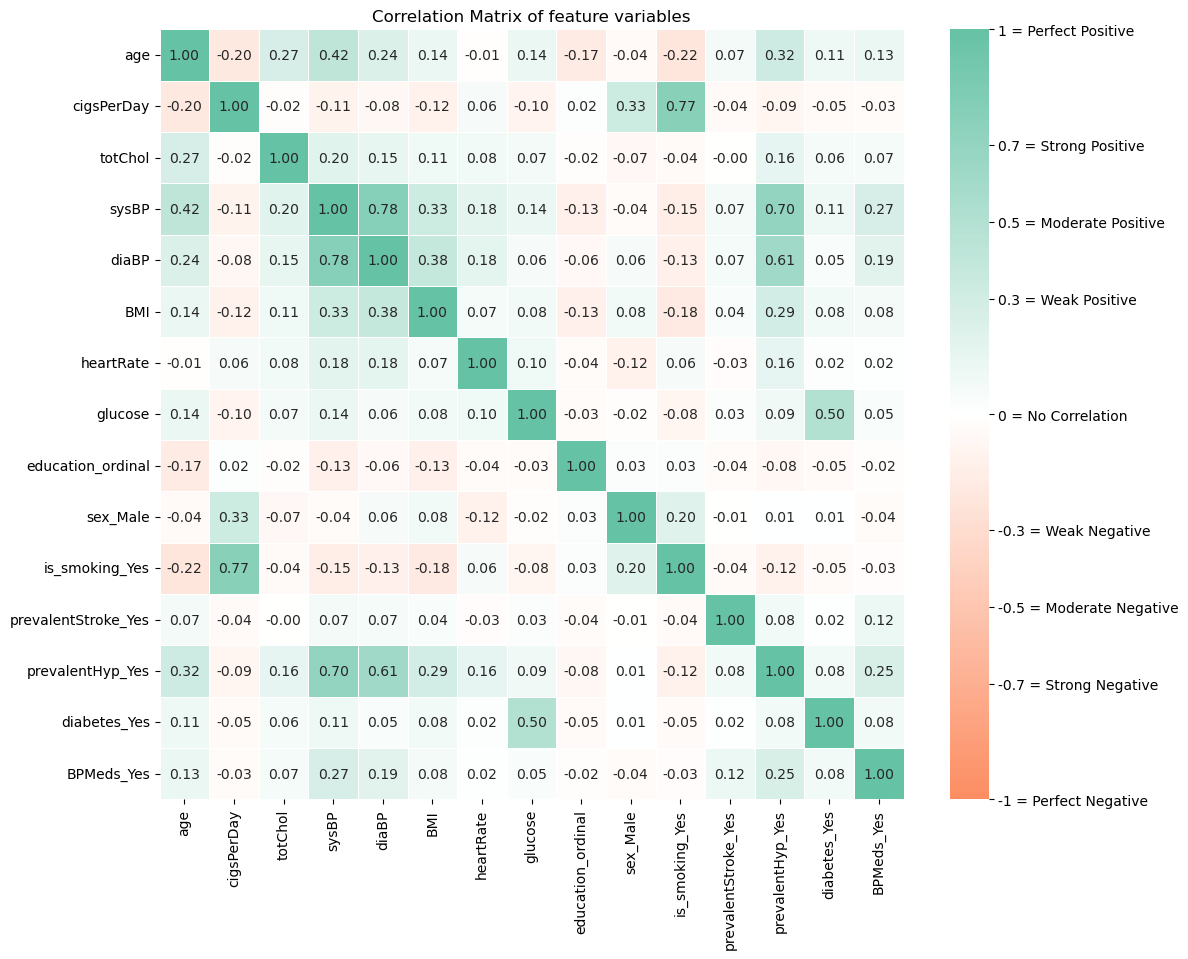

In [97]:
plot_correlation_matrix(x_train_transformed)

Since all values which have VIF score above 2.5 also have strong positive correlations of above 0.7, I will try conducting regression by testing all of them out leaving which one would produce best results. 

#### Picking most appropriate classification metric

Before starting to test and tweak the model, need to decide which metrics will be most important ones when evaluating performance. 
In case of predicting 10-year risk of coronary heart disease, first need to decide what would be worse: 
- False positive - predicting risk when person is actually not in risk.
- False negative - predicting no risk when person is actually at risk. 

CHD is a major cause of death as one of the main complications is a heart attack. According to [NHS](https://www.nhs.uk/conditions/coronary-heart-disease/), it cannot be cured but treatment can help manage the symptoms and reduce the chances of problems such as heart attacks. Thus, I think for our model, it's better to  have false positive than missing to identify risk at all (false negatives). 

However, it's important to remember that it could increase number of people who would get checked and consequence would be money and time spent when it was unneeded.

When model needs to optimize for decreasing amount of false negatives, according to recourses like [Evidently AI](https://www.evidentlyai.com/classification-metrics/accuracy-precision-recall) best metric to use is **Recall**. However, to make sure it does not focus on classifying all instances as positive ones, **Precision** will be taken into account as 2nd priority metric (F2 score). 

#### Cross validation of the model

First, converting y_train back to 0 and 1 as it is not done in the pipeline. 

In [45]:
y_train = y_train.map({"No": 0, "Yes": 1}).astype("Int64")

Next is using cross validation on all variables to check performance metrics. Metrics picked are:
1. **AUC-ROC** - measures the model's ability to distinguish between classes across all classification thresholds, with values closer to 1 indicating better performance.
2. **Precision** - indicates the proportion of true positives among all predicted positives.
3. **Recall** - represents the proportion of true positives correctly identified, focusing on minimizing false negatives.
4. **Log Loss** - quantifies the accuracy of predicted probabilities, with lower values indicating better-calibrated and more confident predictions.

Cross validation will be done on 5 folds. Also, making sure they are shuffled but we could reproduce results using random state. 

In [46]:
scoring = {
    "roc_auc": "roc_auc",                      
    "precision": make_scorer(precision_score),  
    "recall": make_scorer(recall_score),        
    "log_loss": make_scorer(
        log_loss, 
        greater_is_better=False
    ) 
}

cv_results = cross_validate(
    pipeline_transformer(
        numeric_columns, 
        nominal_columns, 
        education_order
    ),      
    x_train,       
    y_train,       
    cv=StratifiedKFold(
        n_splits=5, 
        shuffle=True, 
        random_state=42
    ),  
    scoring=scoring,  
    return_train_score=True 
)

cv_results_df_full = pd.DataFrame(cv_results)
cv_results_df_full.drop(
    ["fit_time", "score_time"], 
    axis=1, 
    inplace=True
)

cv_results_df_full

,test_roc_auc,train_roc_auc,test_precision,train_precision,test_recall,train_recall,test_log_loss,train_log_loss
0,0.727369,0.730792,0.276382,0.263990,0.670732,0.663609,-11.350764,-11.881610
1,0.735093,0.731951,0.281081,0.266100,0.634146,0.669725,-10.819734,-11.831757
2,0.734783,0.732201,0.282723,0.262530,0.658537,0.672783,-10.972699,-12.042234
3,0.731575,0.733012,0.250000,0.268351,0.682927,0.681957,-12.901234,-11.826305
4,0.684529,0.743755,0.219298,0.278729,0.617284,0.695122,-13.898752,-11.460885


- The test **ROC-AUC** ranges from 0.684 to 0.735, indicating good ability to distinguish between risk and no-risk cases. Train ROC-AUC remains consistent (~0.731–0.744), suggesting minimal overfitting.
- Test **precision** is low (21.9%–28.2%), reflecting the model's challenges in achieving high confidence for predicted positives.
- Test **recall** ranges from 61.7% to 68.3%, demonstrating the model’s effectiveness in identifying actual risk cases.
- Test **log loss** goes from -10.8 to -13.89, showing some variability. 

Adjusting decision thresholds based on precision-recall trade-offs will further balance false positives and false negatives. Also, tuning the model to try out different parameters like regularization could help make it more accurate. That's what's gonna be done next. 

#### Hypertuning  

Grid search with TunedThresholdClassifierCV is used to optimize the classifier's hyperparameters and thresholds to maximize performance. 

Classifier Parameters:
- Regularization strength (C) to control overfitting/underfitting.
- Penalty type for regularization.
- Solver to handle optimization.

Preprocessing Parameters:

- Number of neighbors (n_neighbors) for imputation of numerical, educational, and medication-related features.

Thresholds:
- Custom decision thresholds to optimize the balance between precision and recall, focusing on metrics like F2 score.

Purpose:

By iterating over a wide range of parameters and thresholds using parallel processing (using all but 1 CPUs), the process ensures the final model:

- Maximizes the F2 score for optimal recall and balanced precision, critical for imbalanced datasets.
- Minimizes log loss to ensure well-calibrated probabilistic predictions.
- Identifies the best combination of classifier, preprocessing, and threshold configurations by using below visible parameter grid.

This time, to speed up performance, cross validation was reduced to 3 times. Also, custom function was created to make it easier to use in next steps. 

In [47]:
x_train_features = x_train

def tuning(x_train_features):
    numeric_columns = [
    col for col in x_train_features.columns 
    if x_train_features[col].dtype in ["float64", "int64"]
    ]

    nominal_columns = [
        col for col in x_train_features.columns 
        if col not in ["education", "TenYearCHD", "BPMeds"] 
        and x_train_features[col].dtype.name == "category"
    ]

    f2_scorer = make_scorer(
        fbeta_score, 
        beta=3
    )

    pipeline_instance = pipeline_transformer(
        numeric_columns, 
        nominal_columns, 
        education_order
    )

    tuned_clf = TunedThresholdClassifierCV(
        estimator=pipeline_instance,
        cv=StratifiedKFold(
            n_splits=3, 
            shuffle=True, 
            random_state=42
        ),
        scoring=f2_scorer
    )

    optimization_scoring = {
        "f2": f2_scorer,
        "log_loss": "neg_log_loss"
    }

    thresholds = np.arange(0.25, 0.5, 0.05).round(2).tolist()
    neighbors_count = [3, 5]
    C_number = [0.001, 0.005, 0.01, 0.1, 0.5]

    param_grid = [
        {
            "estimator__classifier__C": C_number,
            "estimator__classifier__penalty": ["l2"],
            "estimator__classifier__solver": ["lbfgs"], 
            "estimator__preprocessor__num__imputer__n_neighbors": neighbors_count,
            "estimator__preprocessor__edu__imputer__n_neighbors": neighbors_count,
            "estimator__preprocessor__meds__imputer__n_neighbors": neighbors_count,
            "thresholds": [thresholds]
        },
        {
            "estimator__classifier__C": C_number,
            "estimator__classifier__penalty": ["l1", "l2"],
            "estimator__classifier__solver": ["liblinear"],
            "estimator__preprocessor__num__imputer__n_neighbors": neighbors_count,
            "estimator__preprocessor__edu__imputer__n_neighbors": neighbors_count,
            "estimator__preprocessor__meds__imputer__n_neighbors": neighbors_count,
            "thresholds": [thresholds]
        },
        {
            "estimator__classifier__C": C_number,
            "estimator__classifier__penalty": ["elasticnet"],
            "estimator__classifier__solver": ["saga"],
            "estimator__classifier__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9], 
            "estimator__preprocessor__num__imputer__n_neighbors": neighbors_count,
            "estimator__preprocessor__edu__imputer__n_neighbors": neighbors_count,
            "estimator__preprocessor__meds__imputer__n_neighbors": neighbors_count,
            "thresholds": [thresholds]
        },
        {
            "estimator__classifier__C": C_number,
            "estimator__classifier__penalty": ["l2"],  
            "estimator__classifier__solver": ["newton-cholesky"], 
            "estimator__preprocessor__num__imputer__n_neighbors": neighbors_count,
            "estimator__preprocessor__edu__imputer__n_neighbors": neighbors_count,
            "estimator__preprocessor__meds__imputer__n_neighbors": neighbors_count,
            "thresholds": [thresholds]
        }
    ]

    grid_search = GridSearchCV(
        estimator=tuned_clf,  
        param_grid=param_grid,
        scoring=optimization_scoring,
        cv=StratifiedKFold(
            n_splits=3, 
            shuffle=True, 
            random_state=42
        ),
        n_jobs = -2,
        refit="f2"  
    )

    grid_search.fit(
        x_train_features, 
        y_train
    )
    
    print("Best Parameters Found:")
    for param, value in grid_search.best_params_.items():
        if param != "thresholds":
            print(f"{param}: {value}")

    best_tuned_clf = grid_search.best_estimator_

    cv_results = cross_validate(
        best_tuned_clf,      
        x_train_features,       
        y_train,       
        cv=StratifiedKFold(
            n_splits=3, 
            shuffle=True, 
            random_state=42
        ),  
        scoring=scoring,  
        return_train_score=True,
        return_estimator=True
    )

    decision_threshold = pd.Series(
        [est.best_threshold_ for est in cv_results["estimator"]],
    )

    cv_results_df = pd.DataFrame(cv_results)
    cv_results_df["estimator"] = decision_threshold
    cv_results_df.drop(
        ["fit_time", "score_time"], 
        axis=1, 
        inplace=True
    )
    
    return cv_results_df

tuning_results_full = tuning(x_train_features)

tuning_results_full

Best Parameters Found:
estimator__classifier__C: 0.1
estimator__classifier__l1_ratio: 0.5
estimator__classifier__penalty: elasticnet
estimator__classifier__solver: saga
estimator__preprocessor__edu__imputer__n_neighbors: 3
estimator__preprocessor__meds__imputer__n_neighbors: 3
estimator__preprocessor__num__imputer__n_neighbors: 3


,estimator,test_roc_auc,train_roc_auc,test_precision,train_precision,test_recall,train_recall,test_log_loss,train_log_loss
0,0.3,0.733562,0.725083,0.194401,0.183883,0.912409,0.922794,-21.131788,-22.626962
1,0.3,0.731560,0.730985,0.185185,0.190120,0.919118,0.930403,-22.367798,-21.949150
2,0.3,0.703805,0.744504,0.186490,0.192278,0.933824,0.912088,-22.447541,-21.331144


After trying out a couple of different parameter interval variations, the above shown code provided best results so far. It's important to note that it increased log loss almost 2 times and decreased precision by around 0.1. However, recall increased up to 0.93. Because this model is meant to identify risk, not if condition is actually present, I considered this acceptable for now. 

Next, tried to run it by removing multicorelating variables to ensure they are not causing issues in the model and if it could be improved further.

In [48]:
x_train_features = x_train.drop(
    ["is_smoking", "sysBP"],
    axis=1
)

tuning_results_VIF_removed_smoke_sys = tuning(x_train_features)

tuning_results_VIF_removed_smoke_sys 

Best Parameters Found:
estimator__classifier__C: 0.1
estimator__classifier__l1_ratio: 0.1
estimator__classifier__penalty: elasticnet
estimator__classifier__solver: saga
estimator__preprocessor__edu__imputer__n_neighbors: 3
estimator__preprocessor__meds__imputer__n_neighbors: 3
estimator__preprocessor__num__imputer__n_neighbors: 5


,estimator,test_roc_auc,train_roc_auc,test_precision,train_precision,test_recall,train_recall,test_log_loss,train_log_loss
0,0.25,0.735085,0.721299,0.182706,0.171937,0.956204,0.959559,-23.603808,-25.278403
1,0.25,0.728621,0.730398,0.172275,0.177343,0.941176,0.963370,-24.839819,-24.520848
2,0.25,0.700751,0.742766,0.173740,0.180926,0.963235,0.945055,-25.039175,-23.583873


In [49]:
mean_smoke_sys = (tuning_results_VIF_removed_smoke_sys - tuning_results_full).mean()

In [50]:
x_train_features = x_train.drop(
    ["is_smoking", "diaBP"], 
    axis=1
)

tuning_results_VIF_removed_smoke_dia = tuning(x_train_features)

tuning_results_VIF_removed_smoke_dia 

Best Parameters Found:
estimator__classifier__C: 0.005
estimator__classifier__penalty: l2
estimator__classifier__solver: liblinear
estimator__preprocessor__edu__imputer__n_neighbors: 3
estimator__preprocessor__meds__imputer__n_neighbors: 3
estimator__preprocessor__num__imputer__n_neighbors: 5


,estimator,test_roc_auc,train_roc_auc,test_precision,train_precision,test_recall,train_recall,test_log_loss,train_log_loss
0,0.35,0.727167,0.720837,0.188906,0.179523,0.919708,0.941176,-22.008956,-23.643680
1,0.40,0.736462,0.724046,0.205042,0.197995,0.897059,0.868132,-19.417322,-19.855906
2,0.35,0.701517,0.741001,0.181818,0.186627,0.955882,0.930403,-23.563937,-22.447541


In [51]:
mean_smoke_dia = (tuning_results_VIF_removed_smoke_dia - tuning_results_full).mean()

In [52]:
x_train_features = x_train.drop(
    ["cigsPerDay", "diaBP"], 
    axis=1
)

tuning_results_VIF_removed_cigs_dia = tuning(x_train_features)

tuning_results_VIF_removed_cigs_dia 

Best Parameters Found:
estimator__classifier__C: 0.5
estimator__classifier__l1_ratio: 0.1
estimator__classifier__penalty: elasticnet
estimator__classifier__solver: saga
estimator__preprocessor__edu__imputer__n_neighbors: 3
estimator__preprocessor__meds__imputer__n_neighbors: 3
estimator__preprocessor__num__imputer__n_neighbors: 3


,estimator,test_roc_auc,train_roc_auc,test_precision,train_precision,test_recall,train_recall,test_log_loss,train_log_loss
0,0.25,0.731868,0.725832,0.180672,0.173449,0.941606,0.955882,-23.643680,-24.939497
1,0.30,0.723671,0.731961,0.189313,0.190548,0.911765,0.930403,-21.650115,-21.889343
2,0.30,0.711282,0.738843,0.186490,0.190476,0.933824,0.908425,-22.447541,-21.510565


In [53]:
mean_cigs_dia = (tuning_results_VIF_removed_cigs_dia - tuning_results_full).mean()

In [54]:
x_train_features = x_train.drop(
    ["cigsPerDay", "sysBP"], 
    axis=1
)

tuning_results_VIF_removed_cigs_sys = tuning(x_train_features)

tuning_results_VIF_removed_cigs_sys 

Best Parameters Found:
estimator__classifier__C: 0.1
estimator__classifier__l1_ratio: 0.9
estimator__classifier__penalty: elasticnet
estimator__classifier__solver: saga
estimator__preprocessor__edu__imputer__n_neighbors: 3
estimator__preprocessor__meds__imputer__n_neighbors: 3
estimator__preprocessor__num__imputer__n_neighbors: 3


,estimator,test_roc_auc,train_roc_auc,test_precision,train_precision,test_recall,train_recall,test_log_loss,train_log_loss
0,0.3,0.722409,0.722285,0.186260,0.182857,0.890511,0.941176,-21.849471,-23.125353
1,0.3,0.724849,0.724976,0.185567,0.182671,0.926471,0.926740,-22.447541,-22.965868
2,0.3,0.705021,0.733846,0.183239,0.185736,0.948529,0.915751,-23.205095,-22.307991


In [55]:
mean_cigs_sys = (tuning_results_VIF_removed_cigs_sys - tuning_results_full).mean()

In [56]:
comparison_data = {
    "mean_cigs_sys": mean_cigs_sys,
    "mean_cigs_dia": mean_cigs_dia,
    "mean_smoke_sys": mean_smoke_sys,
    "mean_smoke_dia": mean_smoke_dia
}

comparison_df = pd.DataFrame(comparison_data).T
comparison_df

,estimator,test_roc_auc,train_roc_auc,test_precision,train_precision,test_recall,train_recall,test_log_loss,train_log_loss
mean_cigs_sys,0.000000,-0.005550,-0.006488,-0.003671,-0.005005,0.000054,0.006127,-0.518327,-0.830652
mean_cigs_dia,-0.016667,-0.000702,-0.001312,-0.003200,-0.003936,0.007281,0.009808,-0.598069,-0.810716
mean_smoke_sys,-0.050000,-0.001490,-0.002036,-0.012452,-0.012025,0.031755,0.034233,-2.511892,-2.491956
mean_smoke_dia,0.066667,-0.001260,-0.004896,0.003230,-0.000712,0.002433,-0.008525,0.318970,-0.013290


After creating 4 different variation of removing 2 variables causing most multicollinearity, we can see that the model adapted and improved a little bit. However, it came at a cost of log loss. Recall in training and testing sets improved by at most around 0.03 points. However, the log loss increased, indicating the trade-off between recall improvement and model stability. 

Improvements with least tradeoffs were from model which removed is_smoking and dia_BP columns. It even performed a little bit better on test set during cross validation. Main parameter change was that increased threshold while tuning from 0.3 to 0.35/0.4. It suggests that the model became more cautious in classifying positive cases, improving recall with less false negatives.

However, when it comes to other parameters, best ones were the ones used on full dataset: 

- C: 0.005.
- Penalty: l2
- Solver: liblinear
- Imputer neighbors count: 3 for education and BPMeds, while 5 for numeric columns.

The L2 penalty with the liblinear solver ensures simplicity and stability by reducing the impact of less relevant features, especially in handling smaller datasets prone to noise. The regularization strength (C = 0.005) indicates the model favored stronger regularization to avoid overfitting, prioritizing generalization over fitting noise in the training data. The choice of 3 neighbors for education and BPMeds likely reflects the smaller variability of those features. 

In [57]:
x_train_transformed_dropped = x_train_transformed.drop(
    ["is_smoking_Yes", "diaBP"], 
    axis=1
    )

vif_scoring(x_train_transformed_dropped)

,Feature,VIF
0,prevalentHyp_Yes,2.350133
1,sysBP,2.144110
2,sex_Male,1.644997
3,education_ordinal,1.550579
4,glucose,1.378535
5,diabetes_Yes,1.378225
6,age,1.363513
7,cigsPerDay,1.190043
8,BMI,1.176588
9,BPMeds_Yes,1.135712


The highest VIF score now is around 2.3, which is acceptable. 

There is no need to remove additional variables because the model suggested uses L2 regularization to minimize irrelevant feature impact and handles multicollinearity effectively. Thus, further feature selection should not be needed. However, it can be explored in future improvements. 

Based on all the findings, this version was chosen as the final model. 

### Fitting logistic regression

In [58]:
x_train_features = x_train.drop(
    ["is_smoking", "diaBP"], 
    axis=1
)

numeric_columns = [
    col for col in x_train_features.columns 
    if x_train_features[col].dtype in ["float64", "int64"]
]

nominal_columns = [
    col for col in x_train_features.columns 
    if col not in ["education", "TenYearCHD", "BPMeds"] 
    and x_train_features[col].dtype.name == "category"
]

round_transformer = FunctionTransformer(
    func=lambda X: np.rint(X),
    validate=False
)

numeric_pipeline = Pipeline([
    ("scaler", StandardScaler()),
       ("imputer", KNNImputer(n_neighbors=5))  
])

education_pipeline = Pipeline([
    ("ordinal",
        OrdinalEncoder(
            categories=[education_order],       
            encoded_missing_value=np.nan,
            handle_unknown="use_encoded_value",  
            unknown_value=-1      
        )
    ),
    ("imputer", KNNImputer(n_neighbors=3)),
    ("rounder", round_transformer)
])

nominal_pipeline = Pipeline([
    ("onehot", OneHotEncoder(
        drop="first", 
        sparse_output=False
    ))
])

BPMeds_pipeline = Pipeline([
    ("imputer", KNNImputer(n_neighbors=3)),
       ("rounder", round_transformer) 
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_columns),
    ("edu", education_pipeline, ["education"]),
    ("nominal", nominal_pipeline, nominal_columns),
    ("meds", BPMeds_pipeline, ["BPMeds"])
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced", 
        max_iter=1000,
        C=0.005,
        solver="liblinear",
        penalty="l2"
    ))
])

In [59]:
pipeline.fit(
    x_train_features, 
    y_train
);

In [60]:
y_train_pred_default = pipeline.predict(x_train)

y_train_proba = pipeline.predict_proba(x_train)[:, 1]
threshold = 0.37
y_train_pred_threshold = (y_train_proba >= threshold).astype(int)

print("Classification Report (Default Threshold):")
print(classification_report(y_train, y_train_pred_default))

print("Classification Report (Adjusted Threshold):")
print(classification_report(y_train, y_train_pred_threshold))

Classification Report (Default Threshold):
              precision    recall  f1-score   support

         0.0       0.93      0.65      0.77      2303
         1.0       0.27      0.71      0.39       409

    accuracy                           0.66      2712
   macro avg       0.60      0.68      0.58      2712
weighted avg       0.83      0.66      0.71      2712

Classification Report (Adjusted Threshold):
              precision    recall  f1-score   support

         0.0       0.95      0.34      0.50      2303
         1.0       0.20      0.91      0.32       409

    accuracy                           0.43      2712
   macro avg       0.58      0.62      0.41      2712
weighted avg       0.84      0.43      0.48      2712



In [61]:
baseline = 409/2712 * 100

baseline

15.081120943952802

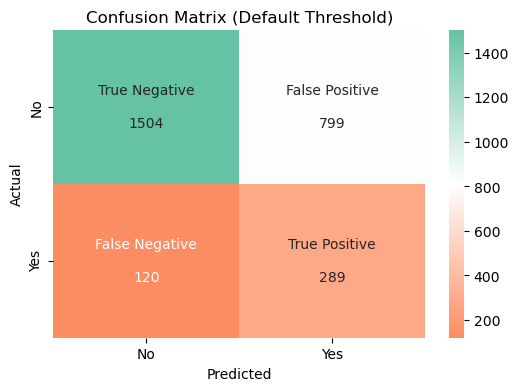

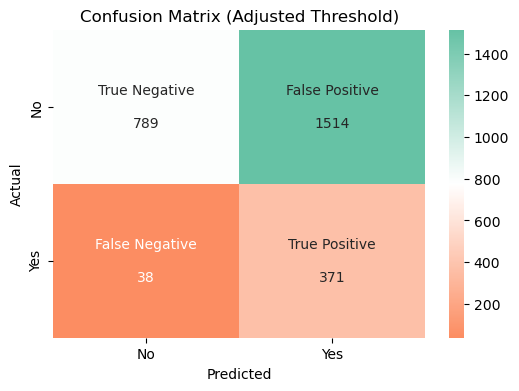

In [93]:
def plot_confusion_matrix(y_true, y_pred, title):
              
    cm = confusion_matrix(
        y_true, 
        y_pred
    )

    annot = np.zeros((2,2), dtype="<U20")
    annot[0,0] = f"True Negative\n\n{cm[0,0]}"
    annot[0,1] = f"False Positive\n\n{cm[0,1]}"
    annot[1,0] = f"False Negative\n\n{cm[1,0]}"
    annot[1,1] = f"True Positive\n\n{cm[1,1]}"

    plt.figure(figsize=(6, 4))

    set2_colors = sns.color_palette("Set2")[:2]

    custom_cmap = LinearSegmentedColormap.from_list(
        "custom", [
            set2_colors[1],
            "white", 
            set2_colors[0]
            ]
        )

    sns.heatmap(
        cm, 
        annot=annot, 
        fmt="", 
        cmap=custom_cmap, 
        xticklabels=["No", "Yes"],
        yticklabels=["No", "Yes"]
    )
    
    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.title(title)

    plt.show()

plot_confusion_matrix(
    y_train, 
    y_train_pred_default, 
    "Confusion Matrix (Default Threshold)"
)

plot_confusion_matrix(
    y_train, 
    y_train_pred_threshold, 
    "Confusion Matrix (Adjusted Threshold)"
)

As seen during cross validation, this configuration improves recall for positive cases (91%) at the expense of recall for negative ones (34%). It decreased overall model accuracy to 43%. However, it's better than baseline because if model would default to predict all cases as positive ones, accuracy and precision would be around 15%. Also, threshold adjustment increased recall from 71% to 91% for positive cases which was the aim. 

Lastly, will display logistic regression coefficients, to help understand which features are contributing the most to the model. 

In [63]:
ct = pipeline.named_steps["preprocessor"]

nominal_subpipeline = ct.named_transformers_["nominal"]

ohe = nominal_subpipeline.named_steps["onehot"]

nominal_feature_names = ohe.get_feature_names_out(nominal_columns)

numeric_feature_names = numeric_columns

education_feature_names = ["education_ordinal"]

BPMeds_feature_names = ["BPMeds_Yes"]

all_feature_names = (
    list(numeric_feature_names)
    + education_feature_names
    + list(nominal_feature_names)
    + BPMeds_feature_names
)

classifier = pipeline.named_steps["classifier"]

coefficients = classifier.coef_[0]  

intercept = classifier.intercept_[0]  

coef_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values(
    by="Coefficient", 
    ascending=False
)

intercept_row = pd.DataFrame([{"Feature": "Intercept", "Coefficient": intercept}])

coef_df = pd.concat(
    [intercept_row, coef_df], 
    ignore_index=True
)

coef_df

,Feature,Coefficient
0,Intercept,-0.151486
1,age,0.386396
2,sysBP,0.245864
3,cigsPerDay,0.241749
4,glucose,0.144469
5,sex_Male,0.132258
6,prevalentHyp_Yes,0.107259
7,totChol,0.088667
8,diabetes_Yes,0.046636
9,prevalentStroke_Yes,0.025455


The coefficient 0.386396 indicates that for every 1 standard deviation increase in age (as the variable was scaled using a standard scaler), the log-odds of CHD increase by approximately 0.39. Age is the most significant contributor to CHD risk in this model, followed by systolic blood pressure (coefficient 0.245864) and the number of cigarettes smoked per day (coefficient 0.241749). These three variables are identified as the top contributors to the model's predictions.

## Results

Finally model was tested out on the test dataset. 

In [64]:
y_test = test["TenYearCHD"]

x_test = test.drop(
    ["TenYearCHD"], 
    axis=1
)

x_test_features = x_test.drop(
    ["is_smoking", "diaBP"], 
    axis=1
)

x_test_features["glucose"] = np.log(x_test_features["glucose"])

# 3
x_test_features["BPMeds"] = x_test_features["BPMeds"].map({"No":0, "Yes":1}).astype("Int64")

numeric_columns = [
    col for col in x_test_features.columns 
    if x_test_features[col].dtype in ["float64", "int64"]
]

nominal_columns = [
    col for col in x_test_features.columns 
    if col not in ["education", "TenYearCHD", "BPMeds"] 
    and x_test_features[col].dtype.name == "category"
]

In [65]:
y_test = y_test.map({"No":0, "Yes":1}).astype("Int64")

In [66]:
y_test_pred_default = pipeline.predict(x_test_features)

y_test_proba = pipeline.predict_proba(x_test_features)[:, 1]
threshold = 0.37
y_test_pred_threshold = (y_test_proba >= threshold).astype(int)

print("Classification Report (Default Threshold):")
print(classification_report(y_test, y_test_pred_default))

print("Classification Report (Adjusted Threshold):")
print(classification_report(y_test, y_test_pred_threshold))

Classification Report (Default Threshold):
              precision    recall  f1-score   support

         0.0       0.92      0.63      0.75       576
         1.0       0.25      0.70      0.37       102

    accuracy                           0.64       678
   macro avg       0.59      0.66      0.56       678
weighted avg       0.82      0.64      0.69       678

Classification Report (Adjusted Threshold):
              precision    recall  f1-score   support

         0.0       0.97      0.32      0.48       576
         1.0       0.20      0.95      0.33       102

    accuracy                           0.41       678
   macro avg       0.59      0.64      0.40       678
weighted avg       0.86      0.41      0.46       678



In [67]:
baseline = 102/678 * 100

baseline

15.04424778761062

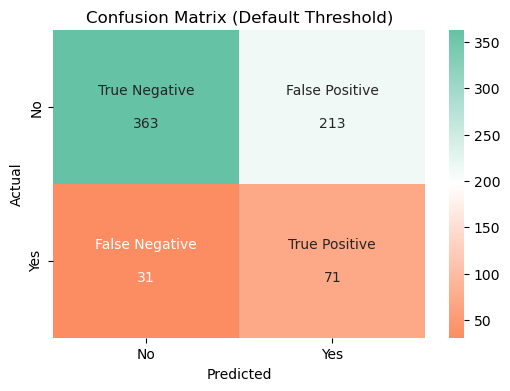

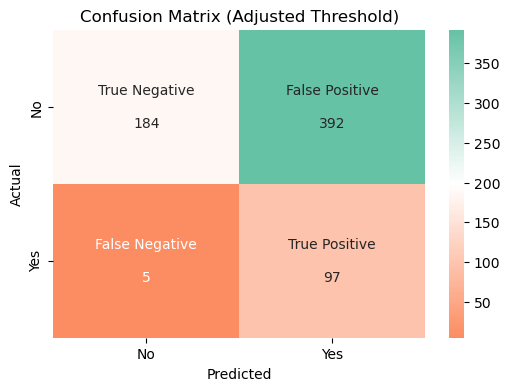

In [88]:
plot_confusion_matrix(
    y_test, 
    y_test_pred_default, 
    "Confusion Matrix (Default Threshold)"
)

plot_confusion_matrix(
    y_test, 
    y_test_pred_threshold, 
    "Confusion Matrix (Adjusted Threshold)"
)

Recall for the minority class (1.0) improved with the adjusted threshold.

- Test set: increased from 70% to 95%.
- Training set: increased from 71% to 91%.
- This highlights the model's improved ability to identify high-risk individuals.

Overall accuracy reduced in both training (66% to 43%) and test (64% to 41%) with the adjusted threshold. However, the model still outperforms the baseline (~15%), focusing on recall for minority class.

Additionally, model having higher minority class recall (70%) than majority class (63%) suggests it isn't heavily biased toward the majority class. 

## Recommendations

As this is project did not test out all possible model improvement techniques, I would not recommend using it in healthcare connext, where predictive outcomes can have serious consequences. However, if it would be used for testing purposes, I would recommend:

1. If used, **continuously track precision, recall, and other metrics in real-world deployments**, especially considering possible data drift, to ensure the model aligns with the intended goals. Additionally, decreasing threshold if higher recall is needed. 
2. **Making sure the recency of medical data is clear** for future training model so that it would be easier to access distribution accuracy. Ensure that data is recent would also make training and testing data reflect current medical practices and behaviors better. 
3. **Starting to track additional variables such as tobacco alternatives in the study.** Their consumption rates are increasing and are present especially among younger people who are still in highschool [(CSD)](https://www.cdc.gov/tobacco/e-cigarettes/youth.html?s_cid=OSH_emg_GL0001&gad_source=1&gclid=Cj0KCQiA4rK8BhD7ARIsAFe5LXJqi-1plgloDCxWMHzUbynqrs2Fo1FNg_ifpU5vu1H-rrbJq7C8JcYaAnOmEALw_wcB). Thus, knowing that smoking is one of the top predictors in this model, tracking affect of it's alternatives would help to improve it. 
4. Additionally, **including other possible risk factors to the data tracking.** Not included in dataset but could be relevant [(based on NHS)](https://www.nhs.uk/conditions/cardiovascular-disease/) are kidney disease, family history, alcohol and more. Including them could help improve the model. 

## Possible analysis improvements

1. **Experimenting with alternative feature scaling techniques.** Testing scaling methods like RobustScaler, which is less sensitive to outliers, or MinMaxScaler, to assess if they result in better performance compared to StandardScaler, particularly for recall and log-loss metrics. 
2. **Refine outlier handling**. Revisit outlier detection and removal strategies, including more aggressive thresholds or domain-specific rules, to evaluate their impact on both training and test set performance. Testing techniques like Z-score-based capping.
3. **Improve how class imbalance is addressed**. Evaluating advanced techniques to handle class imbalance, such as SMOTE (Synthetic Minority Oversampling Technique), oversampling or undersampling. 
4. **Test more complex models.** For example, Random Forest to to assess whether they outperform logistic regression in terms of recall and overall accuracy. 
5. **Integrating established cardiovascular risk scores.** This could enhance model performance by leveraging pre-calculated indicators of CHD risk and providing a benchmark for evaluating model's recall and precision.